# Erith

A procedurally generated world. Most of it is the island of **Portland**:
fractal coastline → orogeny → synthetic topography → particle-based hydraulic
erosion → flow routing → **a river network in which every single watercourse
reaches the sea.**

Sections 8–11 then sketch in the rest of the planet: **Australia**, which is
Menorca scaled up ×80 and pinned to two fixed points, and **Antarctica**,
**South America** and **North America**, which are the real ones roughed up
fractally until they calve their own archipelagos. California is an island, and
a land bridge joins the two Americas.

## What this notebook fixes

The earlier version carried four near-identical copies of the hydrology code
and two copies of the topography build, recomputing the same heightmap several
times. More importantly, its rivers stopped short of the coast. Three bugs
caused that, and all three are fixed here.

| Problem | Why rivers stranded inland | Fix |
|---|---|---|
| **Land/sea decided by `elevation <= 0`** | The ±25 m terrain noise pushed random near-coast land cells below zero, so the router treated them as ocean and gave up short of the shoreline. | The land mask comes from the coastline **polygon**. Land is clamped strictly above sea level; sea carries a real negative depth. |
| **Pit filling by iterative sweeps, capped at 500 passes** | It could exit before converging, leaving cells at `inf` and genuine sinks inland — rivers flowed into a hole and stopped. | **Priority-flood** (Barnes et al.), a heap-based `O(N log N)` fill that provably leaves every land cell a monotone downhill path to the sea. |
| **Rivers patched up afterwards** | `extend_rivers_to_sea`, then a KD-tree drawing straight lines from stranded endpoints to the nearest ocean pixel — cosmetic paint over broken routing. | Not needed. With correct routing, accumulation increases monotonically downstream, so if a cell is a river then everything below it is too, all the way to the sea. **Section 6 asserts this.** |

The ocean also used to render *green*, because a `terrain` colormap spanning
−300…1600 m puts 0 m in the green band and the sea sat at exactly 0 m — so
there was visually no sea for a river to reach. Land and sea now get separate
colormaps, and the land uses atlas hypsometric tints whose class breaks are
bunched low down, where this island actually keeps most of its ground.

## Terrain

The elevation model builds ranges as **wandering crests** carrying their own
along-crest height and width profiles, throwing **spurs** out into the
lowlands, laid down through a **domain-warped** distance field so the contours
buckle into side valleys instead of forming concentric ovals. The plain carries
**rolling downland**; the north carries the high **Idestrian Moor** that the
fjords are cut into. Everything is fractal Brownian motion rather than white
noise, so the country is self-similar at every scale rather than looking like
static.

Two things fell out of building a working drainage network on that terrain:

* **Lakes.** Filled depressions *are* standing water, so they are drawn as
  lakes rather than as rivers. Without that, the ε-gradient priority-flood
  imposes across a flat basin showed up as dead-straight rivers running along
  raster rows.
* **A seaward tilt.** The coastal ramp saturates a few tens of km inland,
  leaving a plain whose regional gradient was weaker than the undulation laid
  on top of it — so the whole lowland closed into basins and flooded. A steady
  `inland_slope` keeps it draining.

## The wider world

Two ways of making a landmass, so far. **Australia** is placed by anchoring two
named points to two positions on the globe, which determines the scale and
bearing of everything else. **Antarctica** and **South America** are built
instead by roughening a real coastline through four different fractal operators
until it is somewhere new — and the roughening folds the coast through itself
hard enough to calve an archipelago and close off inland seas.

The notebook runs end to end in well under a minute.

In [1]:
%matplotlib inline

import textwrap
import time
from dataclasses import dataclass

import matplotlib.patheffects as patheffects
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import BoundaryNorm, LinearSegmentedColormap, ListedColormap
from matplotlib.path import Path as MplPath
from numba import njit
from scipy.ndimage import label, map_coordinates
from scipy.spatial import cKDTree


@dataclass(frozen=True)
class Config:
    """Every tunable in the model lives here."""
    seed: int = 20240607

    # World orientation
    rotation_deg: float = -5.0
    rotation_centre: tuple = (250.0, 400.0)

    # Sampling grid (km).  cell_km drives resolution; the grid stays ~square.
    x_min: float = -100.0
    x_max: float = 550.0
    y_min: float = -250.0
    y_max: float = 1050.0
    cell_km: float = 1.75

    # Elevation model.  The coastal ramp is regional: the northern fjordland
    # climbs fast off the water onto a high moor (which is what gives the
    # fjords their walls), the southern lowlands shelve up slowly.
    lowland_plateau: float = 100.0    # m, height the southern coastal ramp tops out at
    moor_plateau: float = 400.0       # m, ditto for the northern fjordland
    lowland_rise_km: float = 27.0     # e-folding distance of the southern ramp
    moor_rise_km: float = 10.0        # ditto north -- shorter, so the coast is steep
    inland_slope: float = 0.45        # m/km, steady seaward tilt of the lowlands
    min_land_elev: float = 2.0        # m, land is NEVER at or below sea level
    sea_depth: float = 60.0           # m, nominal shelf depth for rendering

    # Hydraulic erosion
    droplets: int = 250_000
    droplet_steps: int = 64

    # River extraction
    river_threshold_km2: float = 900.0   # min upstream area to call it a river
    lake_depth_m: float = 0.5            # fill depth above which a basin holds water
    min_lake_cells: int = 5              # smaller hollows are pits, not lakes

    @property
    def nx(self) -> int:
        return int(round((self.x_max - self.x_min) / self.cell_km)) + 1

    @property
    def ny(self) -> int:
        return int(round((self.y_max - self.y_min) / self.cell_km)) + 1


CFG = Config()
SEA_BLUE = "#aadaff"
rng = np.random.default_rng(CFG.seed)
print(f"Grid: {CFG.nx} x {CFG.ny} cells @ {CFG.cell_km} km  ({CFG.nx * CFG.ny:,} cells)")

plt.rcParams.update({'figure.dpi': 85, 'savefig.bbox': 'tight'})

Grid: 372 x 744 cells @ 1.75 km  (276,768 cells)


## 1. Geometry helpers

The island is authored in unrotated "design" kilometres and rotated 5° at the
end, so its shape can be tweaked without re-deriving every coordinate. Fractal
noise is shared throughout — `_fbm` for coastlines (endpoints pinned) and
`fbm_1d` for profiles running the length of a crest — instead of the three
separate implementations the notebook used to carry.

In [2]:
_ROT = np.radians(CFG.rotation_deg)
_COS, _SIN = np.cos(_ROT), np.sin(_ROT)
_CX, _CY = CFG.rotation_centre


def rotate(x, y):
    """Rotate world coordinates about the island's pivot. Works on scalars,
    arrays, or an (N, 2) array passed as a single argument."""
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    dx, dy = x - _CX, y - _CY
    return _COS * dx - _SIN * dy + _CX, _SIN * dx + _COS * dy + _CY


def rotate_pts(points):
    """Rotate an iterable of (x, y) pairs, returning an (N, 2) array."""
    pts = np.asarray(points, dtype=float)
    return np.column_stack(rotate(pts[:, 0], pts[:, 1]))


def _fbm(n, amplitude, octaves, pin_ends=True):
    """Fractal (multi-octave) 1-D noise of length n."""
    total = np.zeros(n)
    t = np.linspace(0.0, 1.0, n)
    for octave in range(octaves):
        amp = amplitude / (2.0 ** octave)
        knots = max(2, n * (octave + 1))
        layer = np.interp(t, np.linspace(0.0, 1.0, knots),
                          rng.uniform(-amp, amp, knots))
        if pin_ends:
            layer[0] = layer[-1] = 0.0
        total += layer
    return total


def rough_segment(p1, p2, roughness=4.0, steps=20, octaves=3):
    """Fractalise a straight segment by displacing it along its normal."""
    x = np.linspace(p1[0], p2[0], steps)
    y = np.linspace(p1[1], p2[1], steps)
    dx, dy = p2[0] - p1[0], p2[1] - p1[1]
    length = np.hypot(dx, dy)
    if length > 0:
        noise = _fbm(steps, roughness, octaves)
        x += (-dy / length) * noise
        y += (dx / length) * noise
    return np.column_stack([x, y])


def rough_curve(points, roughness=3.0, octaves=3):
    """Apply radial fractal noise to a polyline, pinning its endpoints."""
    pts = np.asarray(points, dtype=float).copy()
    n = len(pts)
    amp = sum(roughness / (2.0 ** o) for o in range(octaves))
    jitter = rng.uniform(-amp, amp, size=(n, 2))
    jitter[0] = jitter[-1] = 0.0
    return pts + jitter


def chain(*segments):
    """Concatenate roughened pieces, dropping duplicated joint vertices."""
    parts = [s[:-1] for s in segments[:-1]] + [segments[-1]]
    return np.vstack(parts)


def fbm_1d(n, seed, octaves=4, base_cells=3, persistence=0.55):
    """Smooth 1-D coherent noise on [0, 1], normalised to ~unit variance.

    Cubic resampling of a small random lattice, summed over octaves. Unlike
    `_fbm` (which pins its endpoints for coastlines) this is used for profiles
    that run the length of a mountain crest.
    """
    gen = np.random.default_rng(seed)
    out = np.zeros(n)
    amp, total = 1.0, 0.0
    for octave in range(octaves):
        cells = base_cells * (2 ** octave)
        lattice = gen.standard_normal(cells + 4)
        coords = np.linspace(1, cells + 1, n)
        out += amp * map_coordinates(lattice, [coords], order=3, mode="reflect")
        total += amp
        amp *= persistence
    out /= total
    return out / (out.std() + 1e-9)


def catmull_rom(control_points, n_out=400):
    """Smooth interpolating spline through the given control points."""
    p = np.asarray(control_points, dtype=float)
    p = np.vstack([2 * p[0] - p[1], p, 2 * p[-1] - p[-2]])
    n_seg = len(p) - 3
    t = np.linspace(0, n_seg, n_out)
    i = np.clip(t.astype(int), 0, n_seg - 1)
    u = (t - i)[:, None]
    p0, p1, p2, p3 = p[i], p[i + 1], p[i + 2], p[i + 3]
    return 0.5 * ((2 * p1) + (-p0 + p2) * u
                  + (2 * p0 - 5 * p1 + 4 * p2 - p3) * u ** 2
                  + (-p0 + 3 * p1 - 3 * p2 + p3) * u ** 3)


def end_taper(n, frac_start=0.12, frac_end=None):
    """Smooth 0->1->0 window so a range dies away instead of stopping dead.

    Either end can be left square (fraction 0), which is what a spur needs
    where it joins its parent crest.
    """
    frac_end = frac_start if frac_end is None else frac_end
    s = np.linspace(0, 1, n)
    a = np.clip(s / frac_start, 0, 1) if frac_start > 0 else np.ones(n)
    b = np.clip((1 - s) / frac_end, 0, 1) if frac_end > 0 else np.ones(n)
    t = np.minimum(a, b)
    return t * t * (3 - 2 * t)


def smoothstep(v, lo, hi):
    t = np.clip((v - lo) / (hi - lo), 0.0, 1.0)
    return t * t * (3 - 2 * t)

## 2. The island of Portland

`build_coastline` assembles the perimeter from roughened segments: the fjorded
north coast, the two bays, the Pres estuary on the west coast, and the twisted
south-west peninsula. `build_range` then turns a handful of control points into
a meandering crest with summits and passes along it, `build_spurs` hangs
subsidiary ridges off its flanks, and `build_world` collects the ranges, the
downlands, the settlements and the labels into one dictionary that every later
stage reads.

In [3]:
def build_coastline():
    """Assemble the fractal perimeter of Portland (unrotated world km)."""
    arc = lambda cx, cy, r, a0, a1, n=35: np.column_stack([
        cx + r * np.cos(np.linspace(a0, a1, n)),
        cy + r * np.sin(np.linspace(a0, a1, n))])

    east_bay = rough_curve(arc(500, 600, 75, np.pi / 2, 3 * np.pi / 2), 8.0)
    west_bay = rough_curve(arc(0, 800, 75, -np.pi / 2, np.pi / 2), 8.0)

    # North coast: a run of fjords separated by open shore.
    fjords = [
        [(0, 1000), (20, 1000), (25, 900), (30, 1000), (100, 1000)],
        [(100, 1000), (90, 920), (110, 850), (115, 930), (120, 1000), (160, 1000)],
        [(160, 1000), (165, 950), (175, 950), (180, 1000), (230, 1000)],
        [(230, 1000), (225, 930), (210, 880), (235, 940), (250, 860),
         (260, 950), (255, 1000), (320, 1000)],
        [(320, 1000), (330, 900), (325, 820), (340, 910), (340, 1000), (360, 1000)],
    ]
    north = chain(*[rough_segment(a, b, 3.5, 15)
                    for run in fjords for a, b in zip(run, run[1:])])

    # The mighty Pres estuary, cut into the west coast.
    estuary = chain(rough_segment((0, 350), (50, 360), 4, 15),
                    rough_segment((50, 360), (90, 380), 3, 12),
                    rough_segment((90, 380), (40, 390), 3, 12),
                    rough_segment((40, 390), (0, 400), 2, 8))

    # East coast, south coast, and the twisted south-west peninsula.
    rim = [((360, 1000), (430, 980), 3, 15), ((430, 980), (480, 930), 4, 15),
           ((480, 930), (500, 850), 4, 15), ((500, 850), (500, 675), 5, 20)]
    tail = [((500, 525), (540, 250), 8, 40), ((540, 250), (480, 50), 6, 35),
            ((480, 50), (450, 0), 3, 10), ((450, 0), (380, -5), 4, 15),
            ((380, -5), (360, -25), 4, 10), ((360, -25), (340, -45), 4, 10),
            ((340, -45), (320, -50), 3, 10), ((320, -50), (150, -50), 5, 30),
            ((150, -50), (150, -15), 3, 10), ((150, -15), (130, -5), 4, 10),
            ((130, -5), (75, 0), 3, 15), ((75, 0), (75, -120), 4, 20),
            ((75, -120), (60, -160), 4, 15), ((60, -160), (20, -190), 4, 15),
            ((20, -190), (-10, -180), 3, 10), ((-10, -180), (0, -150), 3, 10),
            ((0, -150), (-30, 100), 6, 35), ((-30, 100), (0, 350), 6, 35)]
    west = [((0, 400), (-20, 550), 5, 25), ((-20, 550), (0, 725), 5, 25)]
    close = [((0, 875), (0, 950), 4, 15), ((0, 950), (0, 1000), 2, 10)]

    seg = lambda spec: [rough_segment(*s) for s in spec]
    return chain(north, *seg(rim), east_bay, *seg(tail), estuary,
                 *seg(west), west_bay, *seg(close))


def build_range(control_points, crest_height, width, seed, n_points=400,
                wander=10.0, height_variation=0.55, width_variation=0.30,
                taper=(0.12, 0.12)):
    """One mountain range as a wandering crest with a varying skyline.

    A real range is not a straight line of equal peaks: the crest meanders,
    and its height rises and falls into summits and passes. Returns the
    rotated crest plus, for every point along it, the local summit height and
    the local half-width -- both of which the relief model reads back.
    """
    curve = catmull_rom(control_points, n_points)
    tx, ty = np.gradient(curve[:, 0]), np.gradient(curve[:, 1])
    seg = np.hypot(tx, ty)
    seg[seg == 0] = 1e-9

    # Meander perpendicular to the crest's own trend, ends left anchored.
    meander = fbm_1d(n_points, seed, octaves=3, base_cells=2) * wander
    meander *= end_taper(n_points, 0.18)
    sx = curve[:, 0] + (-ty / seg) * meander
    sy = curve[:, 1] + (tx / seg) * meander

    # Skyline: summits and passes along the crest.
    prof = fbm_1d(n_points, seed + 101, octaves=4, base_cells=4)
    prof = (prof - prof.min()) / (np.ptp(prof) + 1e-9)
    heights = crest_height * (1 - height_variation + height_variation * prof)
    heights *= end_taper(n_points, taper[0], taper[1])

    # The range is fatter where it is high, narrower at the passes.
    wprof = fbm_1d(n_points, seed + 202, octaves=3, base_cells=3)
    wprof = (wprof - wprof.min()) / (np.ptp(wprof) + 1e-9)
    widths = width * (1 - width_variation + 2 * width_variation * wprof)

    rx, ry = rotate(sx, sy)
    return dict(x=rx, y=ry, h=heights, w=widths, raw_x=sx, raw_y=sy, seed=seed)


def build_spurs(parent, seed, count=6, length=45.0, side=0.0,
                height_scale=0.55, width_scale=0.55):
    """Short subsidiary ridges thrown off the flanks of a parent range.

    `side` biases which flank they prefer: -1 all one side, +1 the other,
    0 for an even scatter. Spurs are what read as foothills falling away from
    a range front, and they give the drainage network something to braid around.
    """
    gen = np.random.default_rng(seed)
    sx, sy = parent["raw_x"], parent["raw_y"]
    n = len(sx)
    tx, ty = np.gradient(sx), np.gradient(sy)
    seg = np.hypot(tx, ty)
    seg[seg == 0] = 1e-9
    nxv, nyv = -ty / seg, tx / seg

    spurs = []
    anchors = np.linspace(0.12, 0.88, count) + gen.uniform(-0.05, 0.05, count)
    for k, a in enumerate(anchors):
        i = int(np.clip(a, 0.02, 0.98) * (n - 1))
        sign = np.sign(gen.uniform(-1, 1) + side) or 1.0
        length_k = length * gen.uniform(0.65, 1.35)
        skew = gen.uniform(-0.55, 0.55)          # leave the crest obliquely
        dx = sign * nxv[i] + skew * tx[i] / seg[i]
        dy = sign * nyv[i] + skew * ty[i] / seg[i]
        norm = np.hypot(dx, dy)
        dx, dy = dx / norm, dy / norm
        ctrl = [(sx[i], sy[i]),
                (sx[i] + dx * length_k * 0.45 - dy * length_k * 0.12,
                 sy[i] + dy * length_k * 0.45 + dx * length_k * 0.12),
                (sx[i] + dx * length_k, sy[i] + dy * length_k)]
        spur = build_range(
            ctrl, crest_height=parent["h"][i] * height_scale * gen.uniform(0.75, 1.15),
            width=float(np.mean(parent["w"])) * width_scale,
            seed=seed + 17 * k + 3, n_points=120, wander=length_k * 0.10,
            height_variation=0.45, taper=(0.0, 0.35))
        # A spur hangs off its parent: full height at the crest, dying outward.
        spur["h"] *= np.linspace(1.0, 0.30, len(spur["h"])) ** 1.3
        spurs.append(spur)
    return spurs


CENTRAL_DOWNS = [
    dict(name="The Callow Downs", centre=(68, 608), radii=(62, 78), angle=20.0,
         amplitude=330.0, wavelength=34.0, seed=6101, label_rotation=72.0),
    dict(name="The Poress Wolds", centre=(252, 312), radii=(98, 56), angle=-12.0,
         amplitude=305.0, wavelength=30.0, seed=6102, label_rotation=-17.0),
    dict(name="The Gotoe Rises", centre=(392, 138), radii=(62, 66), angle=30.0,
         amplitude=275.0, wavelength=26.0, seed=6103, label_rotation=-5.0),
]
RANGE_SPECS = [
    ("The Alvins",       # the island's spine, NW to SE across Idestria
     [(88, 778), (155, 760), (218, 724), (278, 692), (338, 650), (400, 600)],
     1180, 40, 7, 16.0, 0.50, 71, 9, 58.0, 0.0,
     dict(colour="#5C4033", dark="#4A3020", lw=8, size=250, markers=10),
     dict(asymmetry=0.66, arete=0.16, warp=0.60)),
    ("The Abbots",       # shorter, sharper N-S range walling off the east coast
     [(392, 520), (410, 465), (398, 405), (412, 345), (400, 285)],
     930, 33, 23, 11.0, 0.55, 231, 6, 42.0, -0.45,
     dict(colour="#8B5A2B", dark="#6B4423", lw=5, size=150, markers=6),
     dict(asymmetry=0.60, arete=0.15, warp=0.55)),
    ("The Tenners",      # the fjordland block the northern fjords are cut into
     [(30, 872), (105, 890), (185, 872), (262, 896), (340, 912), (415, 944)],
     440, 34, 53, 14.0, 0.55, 531, 8, 62.0, 0.75,
     dict(colour="#6E5237", dark="#4A3020", lw=6, size=170, markers=7),
     dict(asymmetry=0.72, arete=0.18, warp=0.60)),
    ("Southwest Hills",
     [(48, -150), (52, -70), (46, 10), (72, 68), (120, 96), (152, 100)],
     700, 26, 97, 9.0, 0.55, 971, 5, 28.0, 0.0,
     dict(colour="#7A4B27", dark="#5B3A1A", lw=6, size=200, markers=6),
     dict(asymmetry=0.72, arete=0.12, warp=0.50, skirt=0.32)),
    ("Lower Hills",      # a great curve across the south
     [(196, 148), (250, 122), (305, 128), (355, 168), (402, 224)],
     520, 29, 131, 12.0, 0.60, 1311, 7, 34.0, 0.0,
     dict(colour="#8B5A2B", dark="#6B4423", lw=4, size=120, markers=7),
     dict(asymmetry=0.75, arete=0.10, warp=0.55, skirt=0.34)),
]


def build_world():
    """All named features of Portland, in rotated map coordinates."""
    coast = rotate_pts(build_coastline())

    isles = [rotate_pts(rough_curve(
        np.column_stack([cx + rx * np.cos(np.linspace(0, 2 * np.pi, 15)),
                         cy + ry * np.sin(np.linspace(0, 2 * np.pi, 15))]), r))
        for cx, cy, rx, ry, r in [(100, -80, 10, 5, 2.0), (130, -60, 8, 6, 2.0),
                                  (40, -210, 15, 8, 3.0), (10, -220, 6, 4, 1.5)]]

    ranges = {}
    for (name, ctrl, height, width, seed, wander, hvar,
         spur_seed, spur_n, spur_len, spur_side, style, relief) in RANGE_SPECS:
        crest = build_range(ctrl, height, width, seed,
                            wander=wander, height_variation=hvar)
        crest["spurs"] = build_spurs(crest, spur_seed, count=spur_n,
                                     length=spur_len, side=spur_side,
                                     height_scale=0.50)
        crest.update(style)
        crest["relief"] = relief
        ranges[name] = crest

    cities = {name: rotate(cx, cy) for name, (cx, cy) in {
        "Presport": (0, 400), "Gotoe": (480, 50), "Tennerport": (360, 1000),
        "Eastport": (75, -120), "Melgate": (480, 400), "Calling": (240, 400),
        "Parkhead": (20, 395), "Bradbeck": (15, 353)}.items()}

    # (text, position, font size, colour, style, boxed)
    labels = [("IDESTRIA", rotate(415, 760), 16, "#114411", "italic", False),
              ("PORESS", rotate(230, 430), 16, "#114411", "italic", False),
              ("IDESTRIAN MOOR", rotate(452, 848), 8, "#4a3a1a", "italic", True)]

    range_labels = [("The Alvins", rotate(252, 680), -38, 12),
                    ("The Abbots", rotate(368, 400), 85, 10),
                    ("The Tenners", rotate(180, 852), -2, 10)]

    return dict(coast=coast, isles=isles, ranges=ranges, downs=CENTRAL_DOWNS,
                cities=cities, labels=labels, range_labels=range_labels)


WORLD = build_world()

print(f"Coastline: {len(WORLD['coast']):,} vertices, "
      f"{len(WORLD['isles'])} offshore isles, "
      f"{len(WORLD['ranges'])} upland ranges, "
      f"{len(WORLD['downs'])} downlands, "
      f"{len(WORLD['cities'])} settlements")

Coastline: 911 vertices, 4 offshore isles, 5 upland ranges, 3 downlands, 8 settlements


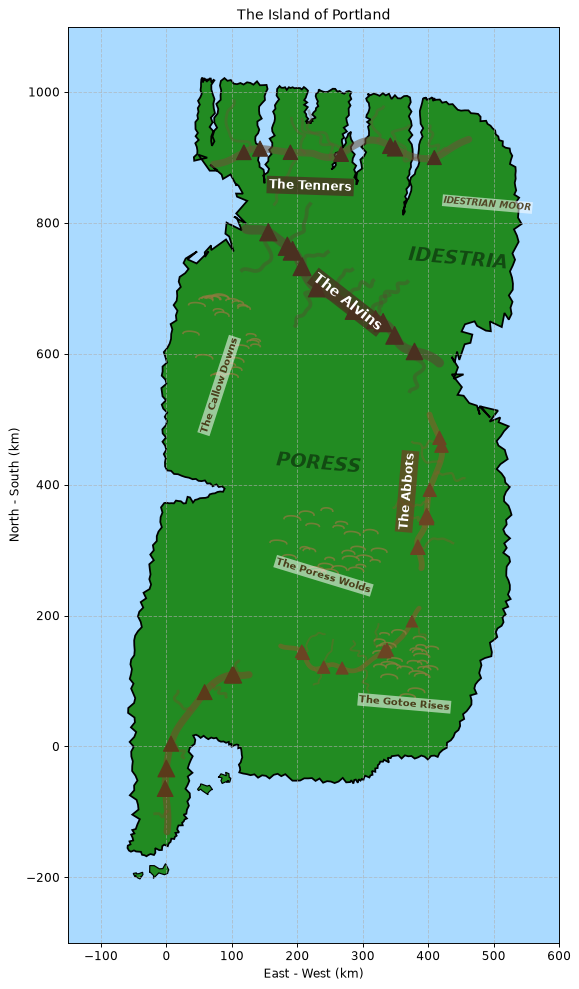

In [4]:
def draw_range(ax, crest):
    """A range as a sinuous ridge line with summit markers on its high points."""
    ax.plot(crest["x"], crest["y"], color=crest["colour"], lw=crest["lw"],
            alpha=0.55, solid_capstyle="round", zorder=4)
    for spur in crest["spurs"]:
        ax.plot(spur["x"], spur["y"], color=crest["colour"],
                lw=crest["lw"] * 0.4, alpha=0.35, zorder=3)

    # Highest point inside each slice of the crest, so markers land on summits.
    h, n = crest["h"], len(crest["h"])
    edges = np.linspace(0, n, crest["markers"] + 1).astype(int)
    idx = [lo + int(np.argmax(h[lo:hi])) for lo, hi in zip(edges[:-1], edges[1:]) if hi > lo]
    idx = [i for i in idx if h[i] > 0.35 * h.max()]
    ax.scatter(crest["x"][idx], crest["y"][idx], marker="^",
               s=crest["size"] * (0.45 + 0.55 * h[idx] / h.max()),
               color=crest["dark"], zorder=5)


def draw_downs(ax, downs):
    """Scattered hachured humps over a downland area -- swells, not summits."""
    gen = np.random.default_rng(downs["seed"])
    cx, cy = downs["centre"]
    rx, ry = downs["radii"]
    theta = np.radians(downs["angle"])

    n_humps = 26
    rad = np.sqrt(gen.uniform(0.0, 0.78, n_humps))   # biased off the very edge
    ang = gen.uniform(0, 2 * np.pi, n_humps)
    u, v = rad * np.cos(ang) * rx, rad * np.sin(ang) * ry
    for x0, y0 in zip(cx + u * np.cos(theta) - v * np.sin(theta),
                      cy + u * np.sin(theta) + v * np.cos(theta)):
        w = gen.uniform(7.0, 13.0)
        t = np.linspace(0, np.pi, 24)
        bx, by = rotate(x0 + w * np.cos(t),
                        y0 + w * gen.uniform(0.32, 0.48) * np.sin(t))
        ax.plot(bx, by, color="#8f7a3f", lw=1.4, alpha=0.75, zorder=4)

    lx, ly = rotate(cx, cy - ry * 0.92)
    ax.text(lx, ly, downs["name"], fontsize=8.5, fontweight="bold",
            color="#4a3f1a", ha="center", va="center", zorder=6,
            rotation=downs["label_rotation"],
            bbox=dict(facecolor="white", alpha=0.55, edgecolor="none", pad=1))


def plot_political(world):
    fig, ax = plt.subplots(figsize=(8, 14))
    ax.set_facecolor(SEA_BLUE)
    ax.add_patch(plt.Polygon(world["coast"], lw=1.5, ec="black", fc="#228B22"))
    for isle in world["isles"]:
        ax.add_patch(plt.Polygon(isle, lw=1.0, ec="black", fc="#228B22"))

    for crest in world["ranges"].values():
        draw_range(ax, crest)
    for downs in world["downs"]:
        draw_downs(ax, downs)

    for name, (lx, ly), rot, fs in world["range_labels"]:
        ax.text(lx, ly, name, fontsize=fs, fontweight="bold", color="white",
                ha="center", va="center", rotation=rot, zorder=6,
                bbox=dict(facecolor=world["ranges"][name]["dark"], alpha=0.75,
                          edgecolor="none", pad=2))

    for text, (lx, ly), fs, colour, style, boxed in world["labels"]:
        ax.text(lx, ly, text, fontsize=fs, fontstyle=style, fontweight="bold",
                color=colour, ha="center", va="center", alpha=0.9, zorder=6,
                rotation=CFG.rotation_deg,
                bbox=dict(facecolor="white", alpha=0.55, edgecolor="none", pad=1)
                if boxed else None)

    ax.set(xlim=(-150, 600), ylim=(-300, 1100),
           xlabel="East - West (km)", ylabel="North - South (km)",
           title="The Island of Portland")
    ax.set_aspect("equal")
    ax.grid(True, linestyle="--", alpha=0.6)
    return fig


plot_political(WORLD)
plt.show()

## 3. Topography

`Relief` binds the noise and relief operators to one sampling grid. Wavelengths
are given in km, so changing `cell_km` re-samples the same island rather than
generating a different one.

Two properties here are what make the hydrology work later:

* the **land mask comes from the polygon**, never from the sign of the elevation;
* **land is clamped to `min_land_elev`**, so noise can never punch a fake lagoon
  into the interior or eat away the coastal strip.

In [5]:
class Relief:
    """Elevation-field builder bound to one sampling grid.

    Landscapes are self-similar -- the same shapes recur at every scale -- so a
    single blob of white noise reads as static rather than as country.
    Everything here is built from fractal Brownian motion instead (coherent
    noise summed over octaves) and from ridges carrying their own along-crest
    height and width profiles.
    """

    def __init__(self, X, Y):
        self.X, self.Y = X, Y
        self.shape = X.shape
        self.span_x = float(X.max() - X.min())
        self.span_y = float(Y.max() - Y.min())
        self._cache = {}

    def fbm(self, seed, base_km=220.0, octaves=6, persistence=0.5):
        """Coherent fractal noise over the grid, normalised to unit variance.

        `base_km` is the wavelength of the coarsest octave; each further octave
        halves it and (by `persistence`) quietens it. Wavelengths are given in
        km, so the result does not change if the grid resolution changes.
        """
        key = (seed, base_km, octaves, persistence)
        if key in self._cache:
            return self._cache[key]

        gen = np.random.default_rng(seed)
        out = np.zeros(self.shape)
        amp, total = 1.0, 0.0
        for octave in range(octaves):
            freq = 2 ** octave
            ny = max(2, int(round(self.span_y / base_km * freq)) + 1)
            nx = max(2, int(round(self.span_x / base_km * freq)) + 1)
            lattice = gen.standard_normal((ny, nx))
            yc, xc = np.meshgrid(np.linspace(0, ny - 1, self.shape[0]),
                                 np.linspace(0, nx - 1, self.shape[1]),
                                 indexing="ij")
            out += amp * map_coordinates(lattice, [yc, xc], order=3, mode="reflect")
            total += amp
            amp *= persistence
        out /= total
        out /= out.std() + 1e-9
        self._cache[key] = out
        return out

    def ridged(self, seed, base_km=90.0, octaves=5):
        """Ridged multifractal noise: creases and aretes, not soft lumps."""
        n = self.fbm(seed, base_km=base_km, octaves=octaves, persistence=0.55)
        return np.clip(1.0 - np.abs(n) / 1.5, 0.0, 1.0) ** 2

    def add_range(self, Z, crest, warp=0.55, crinkle=0.18, asymmetry=0.70,
                  skirt=0.26, arete=0.15):
        """Lay one mountain range onto the elevation field.

        Distance is measured against the whole sinuous crest, but the lookup is
        domain-warped first: each point asks about a position nudged by coherent
        noise. That is what buckles the contours into spurs and side valleys
        instead of concentric ovals, without inflating the range. One flank is
        then made steeper than the other, as a range with any structural grain
        would be, and a low `skirt` carries foothills out into the lowland.
        """
        sx, sy, seed = crest["x"], crest["y"], crest["seed"]
        mean_width = float(np.mean(crest["w"]))

        tree = cKDTree(np.column_stack([sx, sy]))
        warp_x = warp * mean_width * self.fbm(seed + 1301, base_km=130.0, octaves=5)
        warp_y = warp * mean_width * self.fbm(seed + 1302, base_km=130.0, octaves=5)
        dist, nearest = tree.query(
            np.column_stack([(self.X + warp_x).ravel(), (self.Y + warp_y).ravel()]),
            workers=-1)
        dist = dist.reshape(self.shape)
        nearest = nearest.reshape(self.shape)

        # A finer, bounded wobble on top: gullies and buttresses on the flanks.
        fine = np.clip(self.fbm(seed + 1303, base_km=42.0, octaves=4), -1.5, 1.5)
        dist_eff = dist * (1.0 + crinkle * fine)

        # Which flank are we on? Sign of the cross product with the local trend.
        tx, ty = np.gradient(sx), np.gradient(sy)
        seg = np.hypot(tx, ty)
        seg[seg == 0] = 1e-9
        tx, ty = tx / seg, ty / seg
        cross = (tx[nearest] * (self.Y - sy[nearest])
                 - ty[nearest] * (self.X - sx[nearest]))
        half_width = crest["w"][nearest] * np.where(cross > 0, 1.0, asymmetry)
        peak = crest["h"][nearest]

        core = np.exp(-(dist_eff / half_width) ** 2)
        apron = np.exp(-(dist_eff / (2.1 * half_width)) ** 2)
        relief = peak * ((1.0 - skirt) * core + skirt * apron)
        # Roughen the high ground only, so the lowlands stay calm.
        relief += peak * arete * self.ridged(seed + 907, base_km=70.0) * core
        return Z + relief

    def add_downs(self, Z, downs, swell=0.30):
        """Add an area of rolling hills: a broad swell carrying smaller hills.

        Unlike a range this has no crest line -- it is a patch of gently
        undulating country, faded out at its edges so that it blends into the
        surrounding plain.
        """
        cx, cy = rotate(*downs["centre"])
        theta = np.radians(downs["angle"] + CFG.rotation_deg)
        ca, sa = np.cos(theta), np.sin(theta)
        dx, dy = self.X - cx, self.Y - cy
        u = (dx * ca + dy * sa) / downs["radii"][0]
        v = (-dx * sa + dy * ca) / downs["radii"][1]
        r = np.hypot(u, v)

        # Ragged, soft-edged extent so the field does not read as an ellipse.
        edge = self.fbm(downs["seed"] + 55, base_km=90.0, octaves=4)
        extent = np.clip(1.0 - r * (1.0 + 0.18 * edge), 0.0, 1.0) ** 1.4

        hills = self.fbm(downs["seed"], base_km=downs["wavelength"],
                         octaves=4, persistence=0.45)
        # Normalise over this field only -- otherwise a patch that happens to
        # sit in a quiet part of the noise is an imperceptible bulge.
        lo, hi = np.percentile(hills[extent > 0.05], [4, 96])
        hills = np.clip((hills - lo) / (hi - lo + 1e-9), 0.0, 1.0)
        return Z + downs["amplitude"] * extent * (swell + (1.0 - swell) * hills)


def build_terrain(world):
    """Synthesise the base heightmap.

    The land mask comes from the coastline polygon -- never from the sign of
    the elevation.  Land is clamped strictly above sea level so that noise can
    never punch a fake lagoon into the interior, and sea cells carry a real
    negative depth.  Both properties are what let rivers terminate cleanly.
    """
    x_grid = np.linspace(CFG.x_min, CFG.x_max, CFG.nx)
    y_grid = np.linspace(CFG.y_min, CFG.y_max, CFG.ny)
    X, Y = np.meshgrid(x_grid, y_grid)
    pts = np.column_stack([X.ravel(), Y.ravel()])

    land = MplPath(world["coast"]).contains_points(pts)
    for isle in world["isles"]:
        land |= MplPath(isle).contains_points(pts)
    land = land.reshape(X.shape)

    dist_to_coast, _ = cKDTree(world["coast"]).query(pts, workers=-1)
    dist_to_coast = dist_to_coast.reshape(X.shape)

    relief = Relief(X, Y)
    Z = np.zeros(X.shape)

    # Base: how the land climbs away from its own coastline. Deliberately
    # regional -- the northern fjordland rises fast off the water onto a high
    # moor, the southern and central lowlands shelve up slowly.
    northness = smoothstep(Y, 795.0, 900.0)
    northness = np.clip(
        northness + 0.16 * relief.fbm(4001, base_km=170.0, octaves=3)
        * smoothstep(Y, 760.0, 860.0), 0.0, 1.0)
    plateau = (1 - northness) * CFG.lowland_plateau + northness * CFG.moor_plateau
    plateau *= 1.0 + 0.22 * relief.fbm(4002, base_km=150.0, octaves=3)
    rise = (1 - northness) * CFG.lowland_rise_km + northness * CFG.moor_rise_km
    Z += plateau * (1.0 - np.exp(-dist_to_coast / rise))
    # The coastal ramp saturates a few tens of km inland, leaving a plain
    # whose regional gradient is weaker than the undulation laid on top of
    # it -- which turns the whole lowland into closed basins.  A steady
    # seaward tilt keeps the plain draining.
    Z += CFG.inland_slope * dist_to_coast

    # The Idestrian Moor: high, open, dissected ground behind the fjord heads.
    # The fjords are drowned valleys cut into this, which is why they end up
    # with walls rather than beaches.
    moor = smoothstep(Y, 840.0, 950.0) * (1.0 - smoothstep(X, 450.0, 540.0))
    Z += moor * (130.0 + 120.0 * relief.fbm(4003, base_km=95.0, octaves=4))

    # Ranges, each as a main crest plus its spurs. The spurs are narrower and
    # shorter-lived and carry a wider skirt, which reads as foothills falling
    # away from the range front.
    for crest in world["ranges"].values():
        Z = relief.add_range(Z, crest, **crest["relief"])
        for spur in crest["spurs"]:
            Z = relief.add_range(Z, spur, warp=0.45, crinkle=0.20,
                                 asymmetry=0.80, skirt=0.38, arete=0.10)

    for downs in world["downs"]:
        Z = relief.add_downs(Z, downs)

    # A quiet, long-wavelength undulation everywhere, so that even the open
    # plain has a grain to it and the rivers have something to wander around.
    Z += 14.0 * relief.fbm(5101, base_km=120.0, octaves=3)
    Z += 11.0 * relief.fbm(5102, base_km=45.0, octaves=4)
    Z += 4.0 * relief.fbm(5103, base_km=14.0, octaves=3)

    # Sea floor: shelf that deepens away from the coast.
    depth = -np.minimum(CFG.sea_depth, 1.0 + dist_to_coast * 2.0)
    elev = np.where(land, np.maximum(Z, CFG.min_land_elev), depth)

    return dict(x=x_grid, y=y_grid, X=X, Y=Y, relief=relief,
                elev=np.ascontiguousarray(elev), land=land,
                extent=[x_grid[0], x_grid[-1], y_grid[0], y_grid[-1]])


TERRAIN = build_terrain(WORLD)

print(f"Land cells: {TERRAIN['land'].sum():,} "
      f"({100 * TERRAIN['land'].mean():.1f}% of grid), "
      f"max elevation {TERRAIN['elev'][TERRAIN['land']].max():,.0f} m")

Land cells: 165,484 (59.8% of grid), max elevation 1,720 m


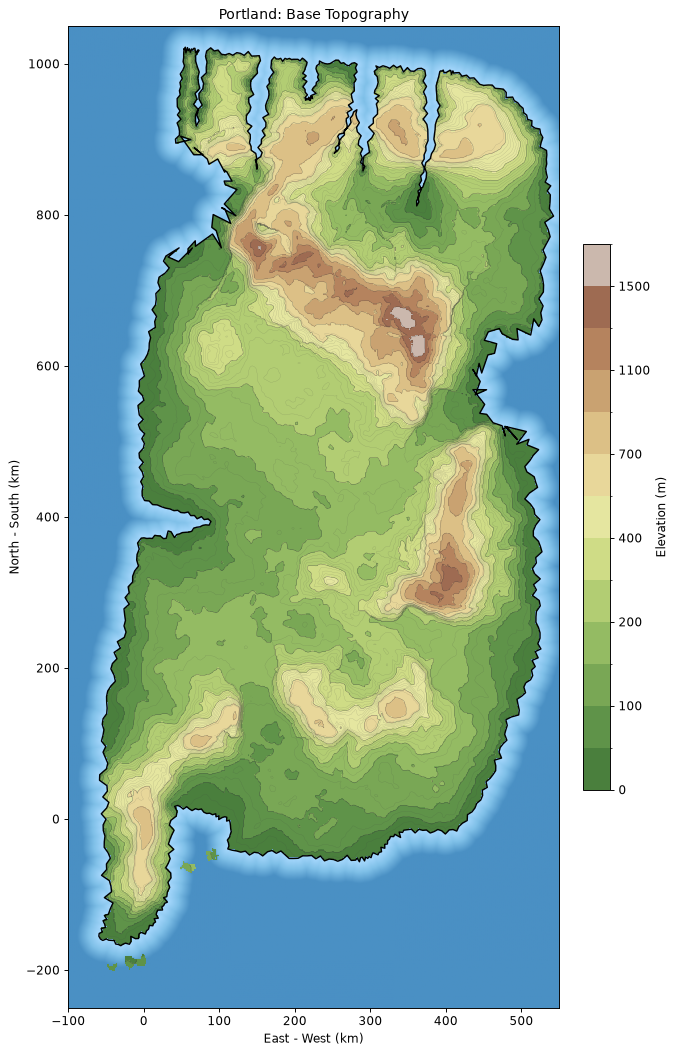

In [6]:
DEEP_BLUE = "#4a90c4"
HYPSO_LEVELS = [0, 50, 100, 150, 200, 300, 400, 550, 700, 900, 1100, 1300, 1500, 1800]
HYPSO_COLOURS = ["#4a7f3d", "#5f9349", "#79a755", "#94bb63", "#b2cd73", "#cfdc86",
                 "#e5e6a0", "#e8d79a", "#dcc086", "#c9a271", "#b5835e", "#9e6b52",
                 "#cbb8ad"]
HYPSO_CMAP = ListedColormap(HYPSO_COLOURS, name="hypso")
HYPSO_CMAP.set_over("#e8e4e0")
HYPSO_CMAP.set_bad(alpha=0.0)
HYPSO_NORM = BoundaryNorm(HYPSO_LEVELS, HYPSO_CMAP.N)


def land_sea_image(ax, elev, land, extent, contours=False):
    """Draw terrain with the sea rendered as sea. Returns the land image."""
    # Deep water as the backdrop, so the axes never show a bare strip where
    # the view extends past the sampled grid.
    ax.set_facecolor(DEEP_BLUE)
    ocean_cmap = LinearSegmentedColormap.from_list(
        "shelf", [DEEP_BLUE, "#7fc0e8", SEA_BLUE])
    ocean_cmap.set_bad(alpha=0.0)
    ax.imshow(np.where(land, np.nan, elev), cmap=ocean_cmap, origin="lower",
              extent=extent, vmin=-CFG.sea_depth, vmax=0.0,
              interpolation="bilinear")

    im = ax.imshow(np.where(land, elev, np.nan), cmap=HYPSO_CMAP,
                   norm=HYPSO_NORM, origin="lower", extent=extent,
                   interpolation="nearest")
    if contours:
        # Fine lines make the shape of the ground readable in the lowlands,
        # where a colour step alone shows almost nothing.
        xs = np.linspace(extent[0], extent[1], elev.shape[1])
        ys = np.linspace(extent[2], extent[3], elev.shape[0])
        ground = np.where(land, elev, np.nan)
        ax.contour(xs, ys, ground, levels=np.arange(25, 600, 25),
                   colors="#3f3f3f", linewidths=0.2, alpha=0.35)
        ax.contour(xs, ys, ground, levels=HYPSO_LEVELS,
                   colors="#3f3f3f", linewidths=0.35, alpha=0.55)
    return im


def plot_topography(terrain, world):
    fig, ax = plt.subplots(figsize=(9, 15))
    im = land_sea_image(ax, terrain["elev"], terrain["land"], terrain["extent"],
                        contours=True)
    ax.plot(*world["coast"].T, color="black", lw=1.2)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Elevation (m)")
    ax.set(xlabel="East - West (km)", ylabel="North - South (km)",
           title="Portland: Base Topography")
    ax.set_aspect("equal")
    return fig


plot_topography(TERRAIN, WORLD)
plt.show()

## 4. Hydraulic erosion

250,000 water droplets, each picking up and dropping sediment as it runs
downhill, carve the valley network the flow router will later follow. A droplet
terminates when it reaches a **sea cell** (from the mask — not from an elevation
test), and erosion is floored at `min_land_elev` so a droplet can never carve a
phantom inlet through the coast.

These kernels deliberately do **not** use `fastmath`. It lets LLVM reassociate
float operations, and the droplet simulation is chaotic enough that the
resulting rounding differences compound into a visibly different island —
freshly compiled and cache-loaded builds stopped agreeing on the result.

In [7]:
@njit(cache=True)
def _height_and_gradient(h, x, y):
    xi, yi = int(x), int(y)
    u, v = x - xi, y - yi
    h00, h10 = h[yi, xi], h[yi, xi + 1]
    h01, h11 = h[yi + 1, xi], h[yi + 1, xi + 1]
    height = h00 * (1 - u) * (1 - v) + h10 * u * (1 - v) + h01 * (1 - u) * v + h11 * u * v
    gx = (h10 - h00) * (1 - v) + (h11 - h01) * v
    gy = (h01 - h00) * (1 - u) + (h11 - h10) * u
    return height, gx, gy


@njit(cache=True)
def _erode_droplet(h, land, x, y, max_steps, floor,
                   inertia=0.1, dt=1.2, erosion_rate=0.05,
                   deposition_rate=0.1, evap_rate=0.02,
                   min_slope=0.01, capacity_mult=4.0):
    rows, cols = h.shape
    dx = dy = 0.0
    velocity, water, sediment = 1.0, 1.0, 0.0

    for _ in range(max_steps):
        height, gx, gy = _height_and_gradient(h, x, y)
        dx = dx * inertia - gx
        dy = dy * inertia - gy
        norm = np.sqrt(dx * dx + dy * dy)
        if norm == 0.0:
            break
        dx /= norm
        dy /= norm

        nx_, ny_ = x + dx * dt, y + dy * dt
        if nx_ < 1.0 or nx_ >= cols - 2 or ny_ < 1.0 or ny_ >= rows - 2:
            break
        # Reaching the sea ends the droplet's life.
        if not land[int(ny_), int(nx_)]:
            break

        new_height, _, _ = _height_and_gradient(h, nx_, ny_)
        delta_h = new_height - height
        capacity = max(-delta_h, min_slope) * velocity * water * capacity_mult

        xi, yi = int(x), int(y)
        u, v = x - xi, y - yi
        w00, w10 = (1 - u) * (1 - v), u * (1 - v)
        w01, w11 = (1 - u) * v, u * v

        if sediment > capacity or delta_h > 0.0:
            amount = ((sediment - capacity) * deposition_rate
                      if delta_h <= 0.0 else min(sediment, delta_h))
            sediment -= amount
        else:
            amount = -min((capacity - sediment) * erosion_rate, -delta_h)
            sediment -= amount

        # Never carve land below the sea: that would create phantom inlets.
        h[yi, xi] = max(h[yi, xi] + amount * w00, floor)
        h[yi, xi + 1] = max(h[yi, xi + 1] + amount * w10, floor)
        h[yi + 1, xi] = max(h[yi + 1, xi] + amount * w01, floor)
        h[yi + 1, xi + 1] = max(h[yi + 1, xi + 1] + amount * w11, floor)

        velocity = np.sqrt(max(velocity * velocity - delta_h * 9.8, 0.01))
        water *= 1.0 - evap_rate
        x, y = nx_, ny_


@njit(cache=True)
def run_erosion(h, land, iterations, max_steps, floor, seed):
    np.random.seed(seed)
    rows, cols = h.shape
    for _ in range(iterations):
        x = np.random.uniform(1.0, cols - 2.0)
        y = np.random.uniform(1.0, rows - 2.0)
        if land[int(y), int(x)]:
            _erode_droplet(h, land, x, y, max_steps, floor)


def erode(terrain):
    eroded = terrain["elev"].copy()
    t0 = time.time()
    run_erosion(eroded, terrain["land"], CFG.droplets, CFG.droplet_steps,
                CFG.min_land_elev, CFG.seed)
    print(f"Eroded with {CFG.droplets:,} droplets in {time.time() - t0:.1f}s")
    return eroded


ERODED = erode(TERRAIN)

Eroded with 250,000 droplets in 0.7s


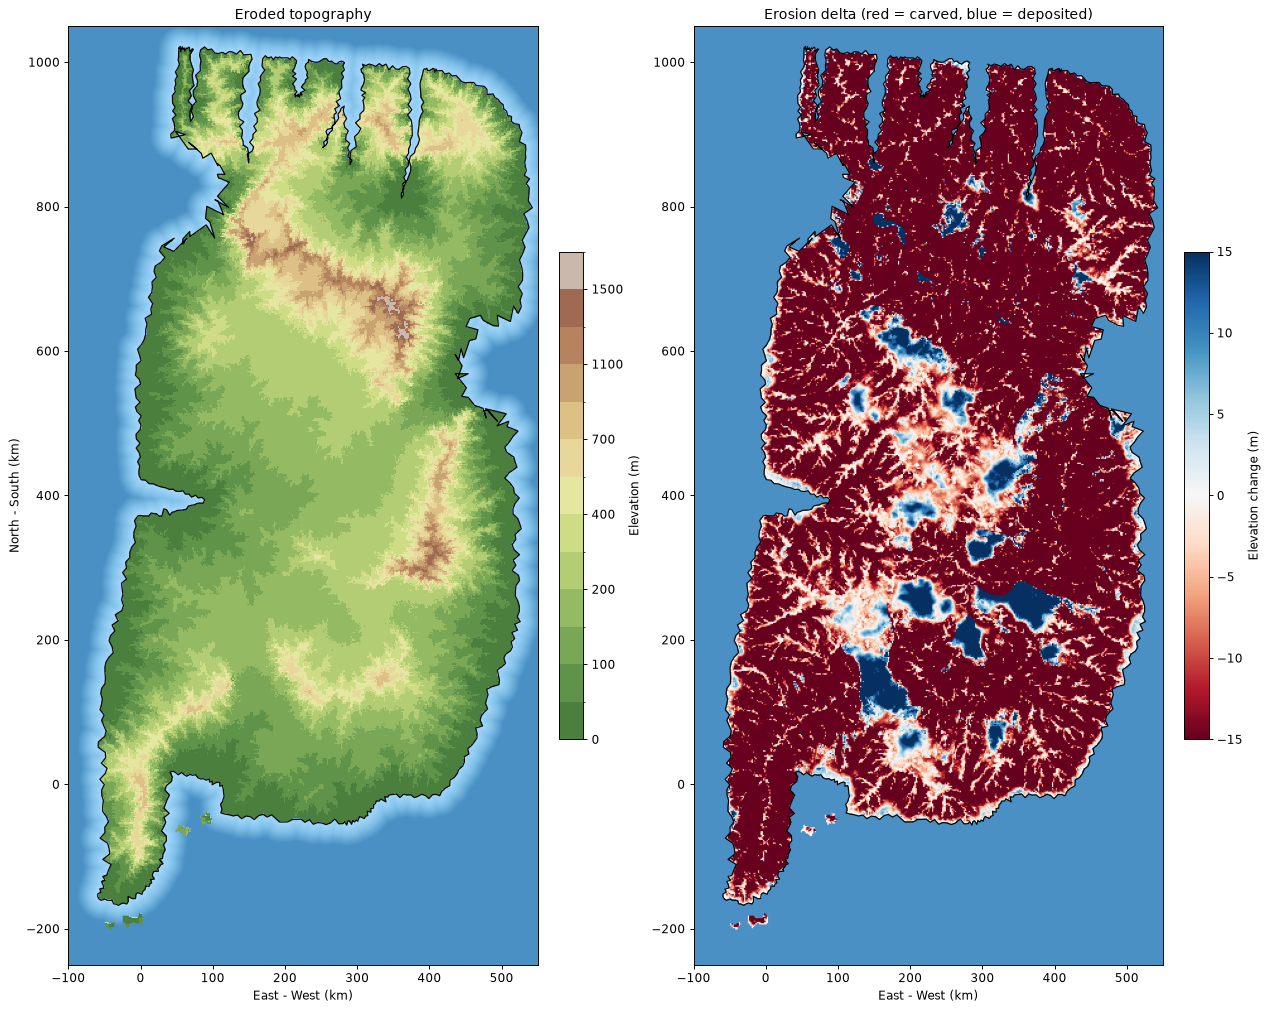

In [8]:
def plot_erosion(terrain, eroded, world):
    delta = np.where(terrain["land"], eroded - terrain["elev"], np.nan)
    fig, axes = plt.subplots(1, 2, figsize=(15, 12))

    im0 = land_sea_image(axes[0], eroded, terrain["land"], terrain["extent"])
    axes[0].set_title("Eroded topography")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="Elevation (m)")

    axes[1].set_facecolor(DEEP_BLUE)
    cmap = plt.get_cmap("RdBu").copy()
    cmap.set_bad(alpha=0.0)
    im1 = axes[1].imshow(delta, cmap=cmap, origin="lower", vmin=-15, vmax=15,
                         extent=terrain["extent"])
    axes[1].set_title("Erosion delta (red = carved, blue = deposited)")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04,
                 label="Elevation change (m)")

    for a in axes:
        a.plot(*world["coast"].T, color="black", lw=1.0)
        a.set_xlabel("East - West (km)")
        a.set_aspect("equal")
    axes[0].set_ylabel("North - South (km)")
    fig.tight_layout()
    return fig


plot_erosion(TERRAIN, ERODED, WORLD)
plt.show()

## 5. Hydrology — the part that used to break

Three steps, each `O(N)` or `O(N log N)`, replacing the four duplicated and
partly-divergent copies the notebook used to run:

1. **`priority_flood`** — fill every depression and impose a tiny (`1e-3` m)
   downhill gradient, working outwards from the coast with a binary heap. Every
   land cell ends up with a strictly lower neighbour, so **no land cell is a
   sink**. This replaces the bounded sweep loop that could quit early.
2. **`d8_flow_direction`** — steepest-descent neighbour for every land cell. A
   land cell touching the sea drains straight into it: that is a river mouth.
3. **`accumulate`** — cascade catchment area downstream in one pass, reusing the
   priority-flood ordering (no separate `argsort`).

The consequence worth stating plainly: because accumulation only ever *increases*
downstream, a cell above the river threshold guarantees every cell below it is
too. **Rivers reach the sea by construction, not by post-hoc patching.**

Depressions the fill had to raise by a real amount are under water, so they are
tagged as lakes. Flow still routes across them to the outlet, which keeps
accumulation correct, but the crossing is drawn as a lake surface. Basins
smaller than `min_lake_cells` are pits in the noise rather than water bodies
and are left alone, so the map shows lakes instead of a dither of blue speckle.

In [9]:
_D8 = np.array([(-1, -1), (-1, 0), (-1, 1), (0, -1),
                (0, 1), (1, -1), (1, 0), (1, 1)], dtype=np.int64)


@njit(cache=True, inline="always")
def _heap_less(heap_val, heap_ord, i, j):
    """Order by elevation, ties broken by insertion order (FIFO).

    The tie-break matters: inside a filled depression the surface is exactly
    flat, so without it equal-priority cells pop in the heap's internal order,
    which correlates with raster order -- and D8 then routes the lake outflow
    along dead-straight grid rows. FIFO makes the flat expand breadth-first
    from its spill point, which drains radially the way a lake actually does.
    """
    if heap_val[i] < heap_val[j]:
        return True
    if heap_val[i] > heap_val[j]:
        return False
    return heap_ord[i] < heap_ord[j]


@njit(cache=True)
def priority_flood(elev, land, epsilon):
    """Barnes et al. priority-flood (+epsilon, FIFO): fill every depression and
    impose a tiny downhill gradient, so *every* land cell has a monotone path
    to the sea.

    Runs in O(N log N) with a binary heap -- the iterative sweep it replaces
    was O(N x iterations) and could exit before converging, which is exactly
    how rivers used to end up stranded inland.

    Returns (filled_elevation, processing_order) where the order is by
    increasing filled elevation -- reusable as the flow-accumulation order.
    """
    rows, cols = elev.shape
    n = rows * cols
    filled = elev.copy()
    closed = ~land                      # sea is already at its final level
    order = np.empty(n, dtype=np.int64)
    n_ordered = 0

    heap_val = np.empty(n, dtype=np.float64)
    heap_ord = np.empty(n, dtype=np.int64)
    heap_idx = np.empty(n, dtype=np.int64)
    size = 0
    pushed = 0

    # Seed: land cells adjacent to the sea (or to the grid edge).
    for y in range(rows):
        for x in range(cols):
            if not land[y, x]:
                continue
            coastal = y == 0 or x == 0 or y == rows - 1 or x == cols - 1
            if not coastal:
                for k in range(8):
                    if not land[y + _D8[k, 0], x + _D8[k, 1]]:
                        coastal = True
                        break
            if not coastal:
                continue
            closed[y, x] = True
            i = size                                     # push
            heap_val[i] = filled[y, x]
            heap_ord[i] = pushed
            heap_idx[i] = y * cols + x
            size += 1
            pushed += 1
            while i > 0:
                p = (i - 1) // 2
                if not _heap_less(heap_val, heap_ord, i, p):
                    break
                heap_val[p], heap_val[i] = heap_val[i], heap_val[p]
                heap_ord[p], heap_ord[i] = heap_ord[i], heap_ord[p]
                heap_idx[p], heap_idx[i] = heap_idx[i], heap_idx[p]
                i = p

    while size > 0:
        val = heap_val[0]
        idx = heap_idx[0]
        size -= 1
        heap_val[0], heap_ord[0], heap_idx[0] = heap_val[size], heap_ord[size], heap_idx[size]
        i = 0
        while True:                                      # sift down
            l, r, small = 2 * i + 1, 2 * i + 2, i
            if l < size and _heap_less(heap_val, heap_ord, l, small):
                small = l
            if r < size and _heap_less(heap_val, heap_ord, r, small):
                small = r
            if small == i:
                break
            heap_val[small], heap_val[i] = heap_val[i], heap_val[small]
            heap_ord[small], heap_ord[i] = heap_ord[i], heap_ord[small]
            heap_idx[small], heap_idx[i] = heap_idx[i], heap_idx[small]
            i = small

        order[n_ordered] = idx
        n_ordered += 1
        y, x = idx // cols, idx % cols

        for k in range(8):
            ny_, nx_ = y + _D8[k, 0], x + _D8[k, 1]
            if ny_ < 0 or nx_ < 0 or ny_ >= rows or nx_ >= cols:
                continue
            if closed[ny_, nx_]:
                continue
            closed[ny_, nx_] = True
            if filled[ny_, nx_] <= val:
                filled[ny_, nx_] = val + epsilon         # carve a downhill slope
            i = size                                     # push neighbour
            heap_val[i] = filled[ny_, nx_]
            heap_ord[i] = pushed
            heap_idx[i] = ny_ * cols + nx_
            size += 1
            pushed += 1
            while i > 0:
                p = (i - 1) // 2
                if not _heap_less(heap_val, heap_ord, i, p):
                    break
                heap_val[p], heap_val[i] = heap_val[i], heap_val[p]
                heap_ord[p], heap_ord[i] = heap_ord[i], heap_ord[p]
                heap_idx[p], heap_idx[i] = heap_idx[i], heap_idx[p]
                i = p

    return filled, order[:n_ordered]


@njit(cache=True)
def d8_flow_direction(filled, land):
    """Steepest-descent neighbour for every land cell.

    A land cell touching the sea drains straight into it -- that is a river
    mouth.  Because priority_flood guarantees a strictly downhill neighbour
    everywhere else, no land cell is ever a sink, so following flow_to from
    anywhere on the island always terminates in the sea.
    """
    rows, cols = filled.shape
    flow_to = np.full(rows * cols, -1, dtype=np.int64)
    for y in range(rows):
        for x in range(cols):
            if not land[y, x]:
                continue
            best_idx, best_drop = -1, 0.0
            for k in range(8):
                ny_, nx_ = y + _D8[k, 0], x + _D8[k, 1]
                if ny_ < 0 or nx_ < 0 or ny_ >= rows or nx_ >= cols:
                    continue
                dist = 1.4142135623730951 if _D8[k, 0] != 0 and _D8[k, 1] != 0 else 1.0
                if not land[ny_, nx_]:          # the sea always wins
                    best_idx = ny_ * cols + nx_
                    best_drop = 1e18
                    break
                drop = (filled[y, x] - filled[ny_, nx_]) / dist
                if drop > best_drop:
                    best_drop = drop
                    best_idx = ny_ * cols + nx_
            flow_to[y * cols + x] = best_idx
    return flow_to


@njit(cache=True)
def accumulate(flow_to, order, cell_area):
    """Cascade catchment area downstream in one pass over the fill order.

    Processing in reverse priority-flood order visits every cell after all of
    its upstream contributors, so accumulation increases monotonically
    downstream -- the property that makes rivers reach the sea by construction.
    """
    acc = np.full(flow_to.size, cell_area, dtype=np.float64)
    for i in range(order.size - 1, -1, -1):
        idx = order[i]
        target = flow_to[idx]
        if target != -1:
            acc[target] += acc[idx]
    return acc


def build_hydrology(terrain, eroded):
    land = terrain["land"]
    t0 = time.time()
    filled, order = priority_flood(eroded, land, epsilon=1e-3)
    flow_to = d8_flow_direction(filled, land)
    cell_area = CFG.cell_km ** 2
    acc = accumulate(flow_to, order, cell_area).reshape(land.shape)

    # Where the fill had to raise the ground by a real amount, the basin is
    # under water: that is a lake, not a hillside.  Flow still routes across it
    # to the outlet (so accumulation stays correct), but the crossing is a lake
    # surface rather than a river, and drawing it as one is what stops the
    # epsilon staircase from showing up as dead-straight rivers along raster
    # rows.  The threshold sits far above the staircase's own few centimetres.
    flooded = land & ((filled - eroded) > CFG.lake_depth_m)
    # Most flooded cells are one- or two-cell hollows in the noise -- pits, not
    # lakes.  Keep only basins big enough to be water bodies, so the map shows
    # lakes rather than a dither of blue speckle.
    components, _ = label(flooded, structure=np.ones((3, 3)))
    sizes = np.bincount(components.ravel())
    big = sizes >= CFG.min_lake_cells
    big[0] = False                           # component 0 is the background
    lake = big[components]
    print(f"Priority-flood + D8 routing + accumulation in {time.time() - t0:.1f}s")
    print(f"  {int(big.sum())} lakes covering "
          f"{lake.sum() * CFG.cell_km ** 2:,.0f} km^2 "
          f"(largest {sizes[1:].max() * CFG.cell_km ** 2:,.0f} km^2)")
    return dict(filled=filled, flow_to=flow_to, acc=acc, order=order, lake=lake,
                depth=np.where(lake, filled - eroded, np.nan))


HYDRO = build_hydrology(TERRAIN, ERODED)

Priority-flood + D8 routing + accumulation in 0.0s
  22 lakes covering 567 km^2 (largest 190 km^2)


## 6. Extracting the rivers — and proving they reach the sea

`verify_rivers` walks *every* river cell downstream, in lock-step, until each one
hits a sea cell. It asserts that none hits an inland sink, and that none is still
on land when the walk ends. If any river stopped short, this cell raises.

In [10]:
def extract_rivers(terrain, hydro):
    """River cells, their downstream segments, and their mouths."""
    land, acc, flow_to = terrain["land"], hydro["acc"], hydro["flow_to"]
    rows, cols = land.shape

    is_river = land & (acc > CFG.river_threshold_km2)
    idx = np.flatnonzero(is_river.ravel())
    tgt = flow_to[idx]
    assert (tgt != -1).all(), "a river cell has no downstream neighbour"

    y0, x0 = np.divmod(idx, cols)
    y1, x1 = np.divmod(tgt, cols)
    to_world = lambda xi, yi: (terrain["x"][0] + xi * CFG.cell_km,
                               terrain["y"][0] + yi * CFG.cell_km)
    p0 = np.column_stack(to_world(x0, y0))
    p1 = np.column_stack(to_world(x1, y1))
    segments = np.stack([p0, p1], axis=1)

    discharge = acc.ravel()[idx]
    mouths = ~land.ravel()[tgt]          # segments that end in the sea

    # A reach that runs from one lake cell to another is the lake's surface,
    # not a river; it gets drawn as open water instead.  Reaches entering or
    # leaving a lake are kept, so every lake visibly has inflows and an outlet.
    flat_lake = hydro["lake"].ravel()
    on_water = flat_lake[idx] & flat_lake[tgt]

    return dict(mask=is_river, segments=segments[~on_water],
                discharge=discharge[~on_water],
                mouth_segments=segments[mouths], mouth_discharge=discharge[mouths])


def verify_rivers(terrain, hydro, rivers):
    """Prove every river drains to the sea; return the trace statistics."""
    land, flow_to = terrain["land"], hydro["flow_to"]
    cols = land.shape[1]
    flat_land = land.ravel()

    idx = np.flatnonzero(rivers["mask"].ravel())
    # Walk every river cell downstream in lock-step until each hits the sea.
    cur = idx.copy()
    steps = np.zeros(idx.size, dtype=np.int64)
    alive = np.ones(idx.size, dtype=bool)
    limit = land.size
    for step in range(limit):
        if not alive.any():
            break
        nxt = flow_to[cur[alive]]
        assert (nxt != -1).all(), "river hit an inland sink"
        cur[alive] = nxt
        steps[alive] = step + 1
        alive[alive] = flat_land[nxt]
    assert not alive.any(), "river failed to reach the sea within the grid"

    stats = dict(river_cells=int(idx.size),
                 mouths=int(rivers["mouth_segments"].shape[0]),
                 max_path_cells=int(steps.max()),
                 longest_km=float(steps.max() * CFG.cell_km),
                 max_discharge_km2=float(rivers["discharge"].max()),
                 lake_km2=float(hydro["lake"].sum() * CFG.cell_km ** 2))
    print(f"  {stats['river_cells']:,} river cells, all reaching the sea")
    print(f"  {stats['mouths']} river mouths on the coast")
    print(f"  longest traced course: {stats['longest_km']:.0f} km")
    print(f"  largest catchment:     {stats['max_discharge_km2']:,.0f} km^2")
    return stats


RIVERS = extract_rivers(TERRAIN, HYDRO)
STATS = verify_rivers(TERRAIN, HYDRO, RIVERS)

  4,926 river cells, all reaching the sea
  73 river mouths on the coast
  longest traced course: 402 km
  largest catchment:     45,282 km^2


## 7. The map — every river reaching the sea

Rivers are drawn as polylines whose width and colour follow discharge, so each
trunk is widest exactly where it crosses the shoreline. Every mouth is marked,
and the inset zooms on the Pres entering the sea beside the capital.

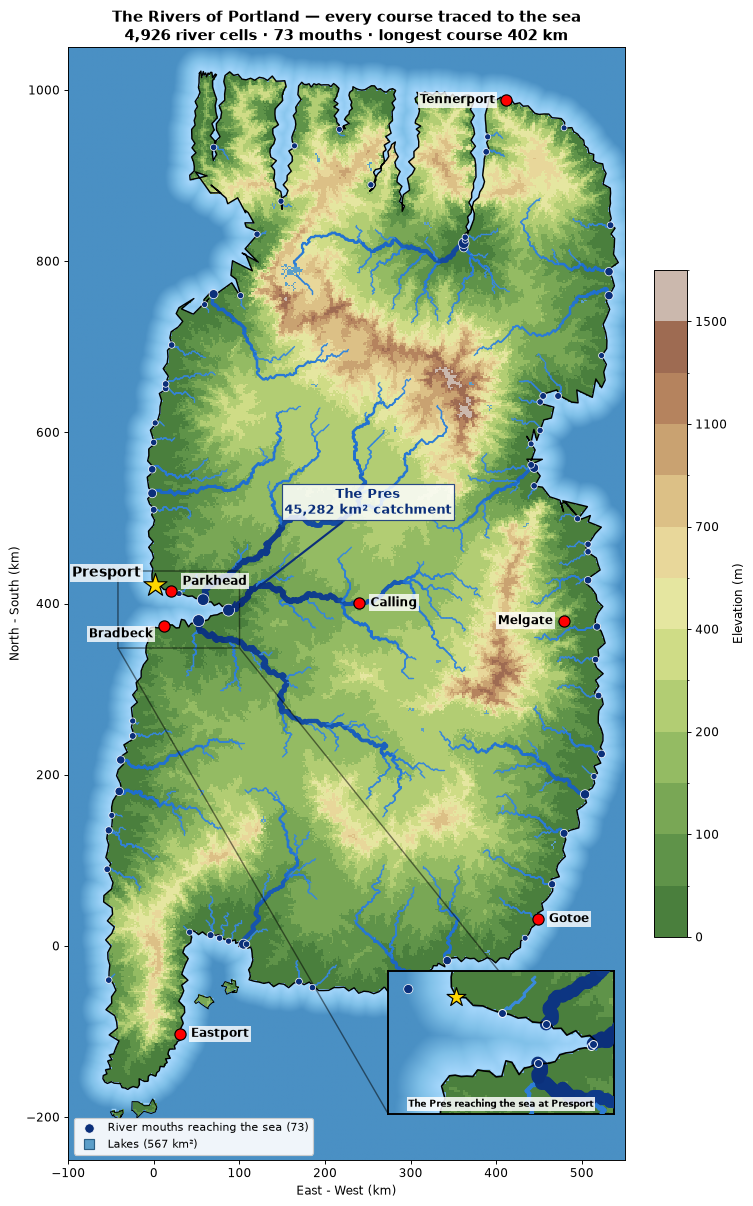

In [11]:
RIVER_CMAP = LinearSegmentedColormap.from_list(
    "rivers", ["#5aa9e6", "#1f6fd0", "#0b2f7a"])
CITY_LABELS = {
    "Presport": (-16, 14, "right"), "Parkhead": (13, 11, "left"),
    "Bradbeck": (-13, -9, "right"), "Calling": (13, 0, "left"),
    "Melgate": (-13, 0, "right"), "Gotoe": (13, 0, "left"),
    "Tennerport": (-13, 0, "right"), "Eastport": (13, 0, "left"),
}
LAKE_BLUE = "#5b9ec9"


def draw_lakes(ax, lake, extent):
    """Filled depressions drawn as the standing water they represent."""
    cmap = ListedColormap([LAKE_BLUE])
    cmap.set_bad(alpha=0.0)
    ax.imshow(np.where(lake, 1.0, np.nan), cmap=cmap, origin="lower",
              extent=extent, interpolation="nearest", zorder=3.5)


def draw_rivers(ax, rivers, dmax, width_scale=1.0):
    """Rivers as tapering polylines: width and colour follow discharge, so each
    trunk is unmistakably widest exactly where it enters the sea."""
    scale = np.sqrt(rivers["discharge"] / dmax)
    ax.add_collection(LineCollection(
        rivers["segments"], linewidths=width_scale * (0.45 + 4.6 * scale),
        colors=RIVER_CMAP(0.15 + 0.85 * scale),
        capstyle="round", joinstyle="round", zorder=4))


def plot_rivers_to_the_sea(terrain, world, hydro, rivers, stats):
    fig, ax = plt.subplots(figsize=(11, 17))
    im = land_sea_image(ax, hydro["filled"], terrain["land"], terrain["extent"])

    dmax = rivers["discharge"].max()
    draw_lakes(ax, hydro["lake"], terrain["extent"])
    draw_rivers(ax, rivers, dmax)

    # Mark every mouth so the terminations are impossible to miss.
    mouth_pts = rivers["mouth_segments"][:, 1, :]
    md = rivers["mouth_discharge"]
    ax.scatter(mouth_pts[:, 0], mouth_pts[:, 1],
               s=12 + 90 * np.sqrt(md / dmax), marker="o",
               facecolor="#0b2f7a", edgecolor="white", linewidth=0.6,
               zorder=6, label=f"River mouths reaching the sea ({stats['mouths']})")
    ax.plot([], [], marker="s", ls="none", color=LAKE_BLUE, markersize=9,
            markeredgecolor="#2c5f85",
            label=f"Lakes ({stats['lake_km2']:,.0f} km\u00b2)")

    ax.plot(*world["coast"].T, color="black", lw=1.2, zorder=5)
    for isle in world["isles"]:
        ax.plot(*isle.T, color="black", lw=0.8, zorder=5)

    for name, (cx, cy) in world["cities"].items():
        capital = name == "Presport"
        dx, dy, ha = CITY_LABELS[name]
        ax.scatter(cx, cy, marker="*" if capital else "o",
                   s=420 if capital else 90, color="gold" if capital else "red",
                   edgecolor="black", zorder=10)
        ax.text(cx + dx, cy + dy, name, fontsize=12 if capital else 10,
                fontweight="bold", ha=ha, va="center", zorder=11,
                bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=1.5))

    # Name the dominant trunk -- it drains into the estuary beside the capital.
    px, py = rivers["mouth_segments"][np.argmax(md), 1]
    ax.annotate(f"The Pres\n{md.max():,.0f} km² catchment", xy=(px, py),
                xytext=(250, 505), fontsize=11, fontweight="bold",
                color="#0b2f7a", ha="center", zorder=12,
                bbox=dict(facecolor="white", alpha=0.85, edgecolor="#0b2f7a", pad=2),
                arrowprops=dict(arrowstyle="->", color="#0b2f7a", lw=1.8))

    # Inset: the estuary in close-up, proving the trunk crosses the shoreline.
    axins = ax.inset_axes([0.575, 0.018, 0.405, 0.175])
    land_sea_image(axins, hydro["filled"], terrain["land"], terrain["extent"])
    draw_lakes(axins, hydro["lake"], terrain["extent"])
    draw_rivers(axins, rivers, dmax, width_scale=2.2)
    axins.plot(*world["coast"].T, color="black", lw=1.4, zorder=5)
    axins.scatter(mouth_pts[:, 0], mouth_pts[:, 1], s=45, facecolor="#0b2f7a",
                  edgecolor="white", linewidth=0.8, zorder=6)
    pcx, pcy = world["cities"]["Presport"]
    axins.scatter(pcx, pcy, marker="*", s=280, color="gold",
                  edgecolor="black", zorder=10)
    axins.set(xlim=(-42, 100), ylim=(348, 438), xticks=[], yticks=[])
    # Caption pinned inside the panel, low where the frame is plain land.
    axins.text(0.5, 0.035, "The Pres reaching the sea at Presport",
               transform=axins.transAxes, ha="center", va="bottom", fontsize=7.5,
               fontweight="bold", zorder=20,
               bbox=dict(facecolor="white", alpha=0.85, edgecolor="none", pad=1.5))
    for spine in axins.spines.values():
        spine.set(edgecolor="black", linewidth=1.6)
    ax.indicate_inset_zoom(axins, edgecolor="black", lw=1.2)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Elevation (m)")
    ax.legend(loc="lower left", framealpha=0.92, fontsize=9)
    ax.set(xlim=(terrain["x"][0], terrain["x"][-1]),
           ylim=(terrain["y"][0], terrain["y"][-1]),
           xlabel="East - West (km)", ylabel="North - South (km)")
    ax.set_title("The Rivers of Portland — every course traced to the sea\n"
                 f"{stats['river_cells']:,} river cells · {stats['mouths']} mouths · "
                 f"longest course {stats['longest_km']:.0f} km",
                 fontsize=13, fontweight="bold")
    ax.set_aspect("equal")
    return fig


plot_rivers_to_the_sea(TERRAIN, WORLD, HYDRO, RIVERS, STATS)
plt.show()

## 8. Spherical geometry

Placing landmasses on Erith needs a handful of sphere primitives: great-circle
distance and bearing, the great-circle midpoint, and an **azimuthal-equidistant**
projection to and from a tangent plane. Distance and bearing from the
projection's centre are exact, which is all any of the constructions below need.

`local_frame` special-cases the poles, where "east" is otherwise undefined —
Antarctica's whole projection is centred on the south pole.

In [12]:
import importlib.util

if importlib.util.find_spec('cartopy') is None:
    %pip install -q cartopy

ERITH_RADIUS_KM = 6371.0
LAT_ORIGIN, LON_ORIGIN = 50.0, 0.0


def km_to_lonlat(x_km, y_km):
    """Project Portland's local map km onto Erith's sphere."""
    x, y = np.asarray(x_km, float), np.asarray(y_km, float)
    lat = LAT_ORIGIN + np.degrees(y / ERITH_RADIUS_KM)
    lon = LON_ORIGIN + np.degrees(x / (ERITH_RADIUS_KM * np.cos(np.radians(lat))))
    return lon, lat


def to_xyz(lon, lat):
    """Unit vectors on the sphere from lon/lat in degrees."""
    lo, la = np.radians(lon), np.radians(lat)
    return np.stack([np.cos(la) * np.cos(lo),
                     np.cos(la) * np.sin(lo),
                     np.sin(la)], axis=-1)


def to_lonlat(v):
    v = v / np.linalg.norm(v, axis=-1, keepdims=True)
    return np.degrees(np.arctan2(v[..., 1], v[..., 0])), np.degrees(np.arcsin(v[..., 2]))


def local_frame(lon, lat):
    """Orthonormal (up, east, north) basis at a point on the sphere.

    At a pole "east" is undefined -- the usual cross product with the polar
    axis collapses to zero -- so the prime meridian is used as the reference
    direction there instead.  Antarctica needs this: its projection is centred
    on the south pole.
    """
    up = to_xyz(lon, lat)
    east = np.cross(np.array([0.0, 0.0, 1.0]), up)
    norm = np.linalg.norm(east)
    if norm < 1e-9:
        east = np.cross(up, np.array([1.0, 0.0, 0.0]))
        norm = np.linalg.norm(east)
    east = east / norm
    return up, east, np.cross(up, east)


def gc_midpoint(a, b):
    m = to_xyz(*a) + to_xyz(*b)
    return to_lonlat(m / np.linalg.norm(m))


def gc_distance_km(a, b):
    return ERITH_RADIUS_KM * np.arccos(np.clip(to_xyz(*a) @ to_xyz(*b), -1.0, 1.0))


def gc_bearing(a, b):
    """Initial bearing from a to b, degrees clockwise from north."""
    _, east, north = local_frame(*a)
    v = to_xyz(*b)
    return np.degrees(np.arctan2(v @ east, v @ north)) % 360.0


def azeq_project(lon, lat, centre):
    """Azimuthal-equidistant projection to km in the plane tangent at `centre`.

    Distance and bearing from the centre are exact; that is all a two-point
    placement needs, and it keeps the construction easy to reason about.
    """
    up, east, north = local_frame(*centre)
    v = to_xyz(np.asarray(lon, float), np.asarray(lat, float))
    delta = np.arccos(np.clip(v @ up, -1.0, 1.0))
    e, n = v @ east, v @ north
    norm = np.hypot(e, n)
    norm = np.where(norm == 0.0, 1.0, norm)
    return ERITH_RADIUS_KM * delta * (e / norm), ERITH_RADIUS_KM * delta * (n / norm)


def azeq_unproject(x, y, centre):
    """Inverse of `azeq_project`."""
    up, east, north = local_frame(*centre)
    d = np.hypot(x, y) / ERITH_RADIUS_KM
    scale = np.where(d == 0.0, 1.0, d) * ERITH_RADIUS_KM
    v = (np.cos(d)[..., None] * up
         + (np.sin(d) * x / scale)[..., None] * east
         + (np.sin(d) * y / scale)[..., None] * north)
    return to_lonlat(v)

## 9. Roughing up a coastline

Erith's **Antarctica**, **South America** and **North America** are the real ones,
reworked. Each base outline is flattened into an **azimuthal-equidistant plane
about its own centre** — the frame all the operators work in, and for Antarctica
the only frame where a pole-encircling coastline is an ordinary closed loop
rather than a mess of antimeridian seams and vertices at latitude −90.

Four ways of roughing a coast up, each doing something the others cannot:

| Operator | What it does | Why it is separate |
|---|---|---|
| `warp_ring` | slides the whole outline through a smooth vector field | moves the **big shapes**, so the result is not just the original with a fuzzy edge |
| `add_lobes` | localised displacement along the outward normal | **bays** and **broad promontories**; amplitude is capped at the half-width, because a bump pushed deeper than it is wide folds the ring through itself |
| `splice_inlet` | *replaces* the arc across a mouth with a path running inland and back | **fjords** are far deeper than they are wide, which no normal displacement can produce |
| `fractal_coast` | multi-octave normal noise, **recomputing normals every octave** | genuine self-similarity: each pass crinkles the crinkles the last pass made |

`repair_ring` then resolves what all that folding produced. Crinkle a coast hard
enough and it passes through itself; rather than fight it, `buffer(0)` turns the
overlaps into valid geometry and hands back a mainland, an **archipelago pinched
off its edges**, and **inland seas** closed off behind it. The fractal process
calves its own islands.

### California is an island

`cut_strait` floods a channel along a path and lets whatever it severs fall out
as a separate polygon — nothing has to know in advance that there is an island
there. North America gets one run up the Gulf of California and out to the
Pacific, leaving the whole western seaboard adrift, the way Spanish cartographers
drew it for most of the 1600s. Both ends of the path must reach open water: a
channel that stops inland is only a very long fjord.

### Measuring it honestly

`box_dimension` measures the coastline **that actually gets drawn**, not the
self-overlapping ring it came from — resolving the folds smooths a great deal
away, and the ring's dimension flatters the result by about 0.3. The same
measure on Natural Earth 50m gives South Africa 1.00, Australia 1.06, Britain
1.12, Norway 1.24; Erith's continents land at 1.09–1.13, with coastlines 2.4 to
3.4 times the shortest that could enclose the same area (Britain 2.9, Norway 4.5).

In [13]:
ANTARCTICA_BASE = dict(
    centre=(0.0, -90.0), ring=np.array([(2496, -1616), (2510, -1489), (2497, -1363),
    (2483, -1259), (2443, -1193), (2410, -1114), (2362, -1028), (2352, -983),
    (2268, -961), (2163, -905), (2116, -830), (1983, -814), (1851, -788),
    (1757, -699), (1757, -567), (1754, -443), (1791, -372), (1844, -309),
    (1781, -256), (1848, -147), (1878, -48), (1893, 10), (1864, 114),
    (1858, 239), (1855, 367), (1835, 431), (1813, 311), (1780, 376),
    (1700, 340), (1640, 268), (1608, 330), (1580, 445), (1544, 569),
    (1626, 601), (1564, 634), (1591, 690), (1579, 737), (1513, 835),
    (1418, 926), (1345, 1039), (1257, 1135), (1165, 1217), (1057, 1253),
    (978, 1280), (856, 1284), (803, 1314), (825, 1239), (771, 1161),
    (730, 1181), (642, 1241), (549, 1308), (498, 1237), (532, 1166),
    (558, 1073), (595, 956), (531, 891), (441, 889), (405, 832), (346, 726),
    (246, 680), (160, 737), (88, 777), (160, 672), (172, 584), (208, 494),
    (112, 582), (-2, 637), (-107, 707), (-172, 762), (-262, 793),
    (-295, 885), (-350, 990), (-383, 1057), (-382, 1156), (-355, 1199),
    (-309, 1249), (-359, 1292), (-438, 1387), (-470, 1509), (-496, 1569),
    (-470, 1655), (-472, 1742), (-436, 1751), (-430, 1823), (-353, 1838),
    (-377, 1918), (-341, 1977), (-372, 2024), (-485, 2088), (-608, 2065),
    (-648, 2023), (-725, 2082), (-836, 2141), (-955, 2124), (-1056, 2146),
    (-1129, 2072), (-1226, 2061), (-1336, 2045), (-1437, 2007),
    (-1491, 2073), (-1590, 2031), (-1706, 1969), (-1810, 1902),
    (-1883, 1833), (-1973, 1758), (-1994, 1644), (-2045, 1552),
    (-2128, 1499), (-2174, 1382), (-2191, 1250), (-2220, 1273),
    (-2272, 1157), (-2290, 1026), (-2338, 1116), (-2458, 1070), (-2481, 944),
    (-2431, 838), (-2515, 743), (-2593, 634), (-2602, 518), (-2570, 397),
    (-2586, 279), (-2598, 155), (-2590, 29), (-2574, -103), (-2535, -227),
    (-2462, -329), (-2395, -446), (-2273, -492), (-2167, -560),
    (-2107, -653), (-1979, -665), (-1851, -682), (-1733, -709),
    (-1798, -755), (-1931, -770), (-2033, -792), (-2078, -820),
    (-2177, -810), (-2295, -853), (-2278, -961), (-2245, -1092),
    (-2189, -1209), (-2162, -1328), (-2100, -1424), (-2187, -1412),
    (-2190, -1542), (-2102, -1643), (-1989, -1642), (-1926, -1689),
    (-1851, -1630), (-1849, -1700), (-1762, -1739), (-1639, -1781),
    (-1510, -1798), (-1394, -1730), (-1353, -1812), (-1314, -1917),
    (-1279, -1984), (-1207, -1876), (-1076, -1897), (-942, -1889),
    (-883, -1991), (-821, -2025), (-719, -1997), (-688, -2071),
    (-600, -2109), (-493, -2162), (-411, -2106), (-320, -2148),
    (-196, -2142), (-65, -2108), (30, -2051), (127, -2068), (212, -2103),
    (284, -2090), (324, -2049), (381, -2033), (413, -1991), (415, -1896),
    (473, -1819), (497, -1730), (466, -1673), (524, -1584), (569, -1497),
    (674, -1416), (741, -1300), (780, -1176), (761, -1046), (649, -1007),
    (548, -1011), (454, -1007), (555, -921), (598, -807), (634, -709),
    (597, -585), (682, -579), (682, -454), (653, -353), (745, -406),
    (804, -361), (822, -423), (920, -367), (966, -295), (1070, -256),
    (1096, -265), (1174, -207), (1237, -149), (1306, -154), (1226, -246),
    (1312, -222), (1309, -287), (1302, -398), (1397, -332), (1426, -404),
    (1413, -524), (1433, -657), (1476, -734), (1484, -775), (1529, -855),
    (1564, -862), (1639, -895), (1666, -941), (1743, -962), (1794, -978),
    (1872, -1015), (1938, -1028), (2063, -1043), (2143, -1080),
    (2173, -1011), (2239, -1016), (2312, -1084), (2351, -1158),
    (2325, -1204), (2319, -1275), (2339, -1270), (2424, -1281),
    (2450, -1379), (2431, -1462), (2481, -1544)]))


def ring_area(xy):
    return 0.5 * abs(np.dot(xy[:, 0], np.roll(xy[:, 1], -1))
                     - np.dot(xy[:, 1], np.roll(xy[:, 0], -1)))


def ring_is_ccw(xy):
    return 0.5 * (np.dot(xy[:, 0], np.roll(xy[:, 1], -1))
                  - np.dot(xy[:, 1], np.roll(xy[:, 0], -1))) > 0


def ring_perimeter(xy):
    return float(np.hypot(*np.diff(np.vstack([xy, xy[:1]]), axis=0).T).sum())


def resample_ring(xy, spacing_km):
    """Resample a closed ring to roughly uniform spacing."""
    seg = np.hypot(*np.diff(np.vstack([xy, xy[:1]]), axis=0).T)
    s = np.concatenate([[0.0], np.cumsum(seg)])
    n = max(16, int(round(s[-1] / spacing_km)))
    t = np.linspace(0.0, s[-1], n, endpoint=False)
    closed = np.vstack([xy, xy[:1]])
    return np.column_stack([np.interp(t, s, closed[:, 0]),
                            np.interp(t, s, closed[:, 1])])


def ring_normals(xy):
    """Outward unit normals of a counter-clockwise ring."""
    tangent = np.roll(xy, -1, axis=0) - np.roll(xy, 1, axis=0)
    tangent /= np.hypot(*tangent.T)[:, None] + 1e-12
    return np.column_stack([tangent[:, 1], -tangent[:, 0]])


def periodic_fbm(n, octaves, seed, lacunarity=2.0, gain=0.5, base_waves=4):
    """Multi-octave noise around a closed loop; wraps seamlessly by construction."""
    gen = np.random.default_rng(seed)
    t = np.linspace(0.0, 2 * np.pi, n, endpoint=False)
    out = np.zeros(n)
    amp, total, waves = 1.0, 0.0, base_waves
    for _ in range(octaves):
        k = max(1, int(round(waves)))
        phase, weight = gen.uniform(0, 2 * np.pi, k), gen.normal(0, 1, k)
        for j, (w, p) in enumerate(zip(weight, phase)):
            out += amp * w * np.sin((k - j) * t + p) / np.sqrt(k)
        total += amp
        amp *= gain
        waves *= lacunarity
    out /= total
    return out / (np.abs(out).max() + 1e-12)


def warp_ring(xy, amplitude_km, waves, seed):
    """Domain warp: slide the whole outline through a smooth vector field.

    This is what stops the result reading as 'Antarctica with a fuzzy edge' --
    the big shapes themselves move.
    """
    n = len(xy)
    return xy + amplitude_km * np.column_stack([
        periodic_fbm(n, 3, seed, base_waves=waves),
        periodic_fbm(n, 3, seed + 1, base_waves=waves)])


def add_lobes(xy, lobes):
    """Displace along the outward normal by localised bumps, in km.

    A wide gentle negative bump is a **bay**; a positive one is a **broad
    promontory**. The amplitude is capped at the half-width: push a bump deeper
    than it is wide and the ring folds through itself.
    """
    perim = ring_perimeter(xy)
    s = np.linspace(0.0, 1.0, len(xy), endpoint=False)
    shift = np.zeros(len(xy))
    for at, half_width_km, amp_km, sharp in lobes:
        capped = float(np.clip(amp_km, -half_width_km, half_width_km))
        width = half_width_km / perim                       # to ring fraction
        d = np.abs((s - at + 0.5) % 1.0 - 0.5) / width
        shift += capped * np.where(d < 1.0,
                                   np.cos(np.pi * np.clip(d, 0, 1) / 2) ** sharp, 0.0)
    return xy + ring_normals(xy) * shift[:, None]


def splice_inlet(xy, at, mouth_km, length_km, seed, sign=-1.0,
                 head_fraction=0.25, meander=0.28, steps=26):
    """Splice a fjord (sign -1) or a narrow promontory (sign +1) into the ring.

    A fjord is far deeper than it is wide, which no normal displacement can
    produce -- push a bump in that far and the coast folds through itself.
    Instead the arc across the mouth is *replaced* by a new path that runs
    inland along one bank and back out along the other, tapering to
    `head_fraction` of the mouth width at its head.
    """
    gen = np.random.default_rng(seed)
    perim = ring_perimeter(xy)
    n = len(xy)

    i = int(at * n) % n
    half = max(1, int(round(0.5 * mouth_km / perim * n)))
    xy = np.roll(xy, -(i - half), axis=0)                   # splice away from the seam
    a, b = xy[0], xy[2 * half]
    rest = xy[2 * half:]

    mid = 0.5 * (a + b)
    axis = ring_normals(xy)[half] * sign                    # inland, or out to sea
    side = np.array([-axis[1], axis[0]])

    t = np.linspace(0.0, 1.0, steps)
    wander = np.cumsum(gen.normal(0, meander, steps))
    wander -= wander[0] + t * (wander[-1] - wander[0])      # pin both ends
    spine = mid + np.outer(t * length_km, axis) + np.outer(wander * length_km * 0.12, side)
    half_w = 0.5 * mouth_km * (1.0 - (1.0 - head_fraction) * t ** 0.75)

    left = spine + side * half_w[:, None]
    right = spine - side * half_w[:, None]
    return np.vstack([a, left, right[::-1], b, rest[1:]])


def fractal_coast(xy, octaves, amplitude_km, seed, gain=0.5, lacunarity=2.2,
                  spacing_km=6.0, base_waves=6):
    """Iteratively roughen the coast, recomputing normals at every scale.

    Displacing along normals that are re-derived after each octave is what
    makes this genuinely self-similar rather than one wobble laid over the
    whole outline: each pass sees the crinkles the previous pass made and
    crinkles those in turn.
    """
    out = resample_ring(xy, spacing_km)
    amp, waves = amplitude_km, base_waves
    for k in range(octaves):
        noise = periodic_fbm(len(out), 2, seed + 17 * k, base_waves=waves)
        out = out + ring_normals(out) * (amp * noise)[:, None]
        amp *= gain
        waves *= lacunarity
    return out


def box_dimension(xy, boxes=(8, 16, 32, 64, 128, 256)):
    """Box-counting dimension of an outline.

    Real coastlines run from about 1.02 (South Africa) to 1.25 (Britain).
    """
    extent = max(np.ptp(xy[:, 0]), np.ptp(xy[:, 1]))
    scales = extent / np.asarray(boxes, dtype=float)
    dense = resample_ring(xy, scales.min() / 4)
    counts = [len(np.unique(np.floor(dense / h).astype(np.int64), axis=0))
              for h in scales]
    return float(np.polyfit(np.log(1 / scales), np.log(counts), 1)[0])


def repair_ring(xy):
    """Resolve a self-overlapping outline into valid geometry.

    Crinkle a coast hard enough and it folds through itself. Rather than fight
    that, the folds are resolved: `buffer(0)` turns the overlaps into valid
    geometry, and what comes back is a mainland, an archipelago pinched off its
    edges, and inland seas closed off behind it. The fractal process calves its
    own islands.
    """
    from shapely.geometry import Polygon                    # ships with cartopy
    return Polygon(xy).buffer(0)


def cut_strait(geom, path_lonlat, centre, width_km):
    """Flood a channel along a path, splitting whatever it separates.

    Used to make California an island, as the Spanish believed it was for most
    of the seventeenth century: a channel run up the Gulf of California and out
    to the Pacific leaves the whole seaboard adrift. Whatever the cut severs
    falls out as a separate polygon on its own -- nothing has to know in advance
    that there is an island there.
    """
    from shapely.geometry import LineString

    px, py = azeq_project(np.array([q[0] for q in path_lonlat], dtype=float),
                          np.array([q[1] for q in path_lonlat], dtype=float), centre)
    return geom.difference(LineString(np.column_stack([px, py]))
                           .buffer(width_km / 2.0))


def rings_from(geom, min_area_km2=1500.0):
    """Split shapely geometry into land rings and inland-sea rings, big first."""
    from shapely.geometry import MultiPolygon, Polygon

    parts = sorted(list(geom.geoms) if isinstance(geom, MultiPolygon) else [geom],
                   key=lambda g: -g.area)
    land = [np.array(g.exterior.coords) for g in parts if g.area >= min_area_km2]
    seas = [np.array(r.coords) for g in parts for r in g.interiors
            if Polygon(r).area >= min_area_km2]
    return land, seas

In [14]:
ANTARCTICA_RECIPE = dict(
    seed=11,
    warp_km=380, warp_waves=3,          # slide the big shapes around
    lobes=[                             # (position, half-width km, km, sharpness)
        (0.07, 900, -800, 2.0), (0.41, 1100, -975, 2.0),    # deep embayments
        (0.58, 700, -625, 1.8),
        (0.73, 620, 650, 1.4), (0.21, 480, 538, 1.2),       # broad promontories
        (0.90, 520, 575, 1.3)],
    fjords=14, fjord_km=700,            # narrow inlets, spliced not pushed
    octaves=7, fractal_km=185, gain=0.55,
    spacing_km=4.0, min_area_km2=1500.0)
NORTH_AMERICA_RECIPE = dict(
    seed=43,
    warp_km=340, warp_waves=3,
    lobes=[(0.22, 1000, -720, 2.0), (0.68, 850, -640, 2.0),   # gulfs and sounds
           (0.45, 700, 600, 1.4), (0.05, 560, 520, 1.3),      # capes
           (0.86, 640, -470, 1.8)],
    fjords=18, fjord_km=620, fjord_span=(0.55, 1.05),         # northern fjordland
    octaves=7, fractal_km=175, gain=0.55,
    # Both ends must reach open water or the channel is only a long fjord.
    # Run well inland of the real coast: the island on Sanson's 1650 map is far
    # bigger than California, reaching from Baja to about 43 N.
    straits=[dict(name="the Strait of California", width_km=120, path=[
        (-108.0, 19.0), (-112.0, 26.0), (-113.5, 30.0), (-114.5, 34.0),
        (-116.0, 38.0), (-117.5, 41.5), (-120.0, 45.0), (-124.0, 48.0),
        (-130.0, 51.0)])],
    spacing_km=4.0, min_area_km2=1500.0)
SOUTH_AMERICA_RECIPE = dict(
    seed=29,
    warp_km=260, warp_waves=4,
    lobes=[(0.15, 800, -560, 2.0), (0.62, 950, -680, 2.0),   # gulfs
           (0.38, 520, 480, 1.4), (0.86, 600, 540, 1.3),     # capes
           (0.05, 450, -360, 1.8)],
    fjords=16, fjord_km=520, fjord_span=(0.45, 0.95),        # a southern fjordland
    octaves=7, fractal_km=150, gain=0.55,
    spacing_km=4.0, min_area_km2=1500.0)
NORTH_AMERICA_BASE = dict(
    centre=(-100.0, 45.0), ring=np.array([
        (-1857, 1524), (-1834, 1535), (-1891, 1396), (-1865, 1337),
        (-1866, 1308), (-1872, 1183), (-1839, 1149), (-1813, 1136),
        (-1811, 1062), (-1821, 980), (-1772, 917), (-1730, 807),
        (-1705, 773), (-1661, 696), (-1640, 560), (-1673, 520), (-1680, 548),
        (-1802, 637), (-1798, 460), (-1817, 411), (-1893, 198), (-1976, 10),
        (-2025, -186), (-2021, -401), (-1951, -509), (-1935, -572),
        (-1932, -675), (-1871, -871), (-1755, -1017), (-1615, -1163),
        (-1576, -1358), (-1521, -1563), (-1391, -1741), (-1489, -1798),
        (-1331, -1923), (-1231, -2088), (-1136, -2264), (-998, -2380),
        (-1081, -2253), (-1151, -2052), (-1207, -1922), (-1294, -1733),
        (-1407, -1554), (-1415, -1336), (-1249, -1447), (-1211, -1656),
        (-1088, -1836), (-972, -1983), (-906, -2101), (-829, -2207),
        (-722, -2319), (-596, -2506), (-565, -2687), (-521, -2851),
        (-336, -2974), (-136, -3064), (73, -3151), (281, -3228),
        (497, -3219), (614, -3186), (718, -3226), (897, -3366),
        (1113, -3417), (1289, -3455), (1431, -3475), (1555, -3593),
        (1643, -3740), (1714, -3748), (1893, -3831), (1980, -3896),
        (2148, -3909), (2282, -3988), (2325, -3855), (2489, -3771),
        (2570, -3803), (2620, -3878), (2627, -3740), (2414, -3697),
        (2228, -3813), (2080, -3801), (1912, -3675), (1870, -3506),
        (1866, -3370), (1878, -3190), (1792, -3132), (1650, -3108),
        (1448, -3152), (1266, -3175), (1292, -2991), (1304, -2847),
        (1351, -2755), (1399, -2590), (1305, -2523), (1089, -2578),
        (1005, -2764), (925, -2911), (732, -2928), (531, -2915),
        (404, -2846), (285, -2657), (278, -2624), (234, -2420), (264, -2195),
        (252, -1988), (285, -1879), (393, -1812), (489, -1699), (593, -1672),
        (760, -1683), (893, -1715), (1031, -1693), (1036, -1624),
        (957, -1574), (1150, -1530), (1249, -1519), (1342, -1528),
        (1467, -1568), (1647, -1585), (1727, -1744), (1796, -1826),
        (1895, -1950), (2000, -1939), (1958, -1737), (1905, -1631),
        (1865, -1569), (1771, -1365), (1804, -1203), (1907, -1106),
        (2021, -973), (2099, -860), (2105, -784), (2159, -697), (2108, -689),
        (2171, -688), (2051, -591), (2034, -556), (2004, -496), (1957, -449),
        (2047, -469), (1997, -355), (2035, -373), (2084, -453), (2127, -498),
        (2090, -324), (2116, -325), (2183, -232), (2158, -100), (2304, -8),
        (2404, 58), (2375, 99), (2339, 265), (2408, 383), (2489, 460),
        (2565, 590), (2672, 700), (2737, 668), (2630, 548), (2647, 429),
        (2744, 555), (2852, 671), (2864, 778), (2692, 732), (2547, 800),
        (2452, 867), (2523, 945), (2424, 1020), (2265, 859), (2188, 648),
        (2047, 476), (1970, 334), (2043, 487), (2169, 666), (2105, 776),
        (2236, 912), (2322, 1091), (2516, 1192), (2704, 1296), (2779, 1497),
        (2827, 1664), (2738, 1774), (2612, 1775), (2537, 1629), (2559, 1720),
        (2526, 1804), (2421, 1799), (2317, 1832), (2207, 1885), (2164, 1947),
        (2098, 2033), (2009, 2065), (1917, 2149), (1910, 2068), (1923, 1947),
        (1835, 1893), (1812, 1850), (1698, 1902), (1605, 1994), (1585, 2100),
        (1445, 2146), (1297, 2138), (1132, 2083), (1207, 1930), (1249, 1791),
        (1348, 1640), (1427, 1435), (1299, 1254), (1396, 1089), (1452, 902),
        (1408, 854), (1288, 937), (1174, 1077), (1081, 1255), (913, 1254),
        (711, 1344), (499, 1374), (422, 1479), (329, 1539), (294, 1737),
        (354, 1910), (393, 1999), (391, 2087), (364, 2116), (490, 2161),
        (611, 2260), (445, 2348), (536, 2330), (600, 2438), (706, 2488),
        (770, 2491), (753, 2673), (728, 2792), (573, 2809), (595, 2636),
        (500, 2589), (427, 2714), (359, 2718), (298, 2777), (266, 2900),
        (159, 2952), (134, 2814), (251, 2711), (268, 2633), (207, 2454),
        (187, 2476), (144, 2590), (108, 2553), (4, 2538), (-196, 2576),
        (-348, 2644), (-250, 2616), (-326, 2468), (-369, 2474), (-453, 2579),
        (-655, 2621), (-659, 2733), (-819, 2861), (-944, 2914),
        (-1027, 2934), (-1088, 2994), (-1206, 2991), (-1299, 2985),
        (-1132, 3036), (-1319, 3027), (-1407, 3028), (-1481, 3152),
        (-1609, 3317), (-1724, 3486), (-1801, 3624), (-1819, 3735),
        (-1976, 3761), (-2048, 3814), (-2258, 3818), (-2356, 3758),
        (-2369, 3572), (-2413, 3556), (-2439, 3517), (-2475, 3644),
        (-2649, 3716), (-2699, 3606), (-2644, 3462), (-2591, 3380),
        (-2732, 3345), (-2864, 3400), (-3003, 3366), (-3053, 3281),
        (-3061, 3224), (-3123, 3155), (-3003, 3123), (-3136, 2980),
        (-3057, 2884), (-3005, 2841), (-2991, 2761), (-3136, 2698),
        (-3333, 2704), (-3434, 2750), (-3519, 2722), (-3431, 2677),
        (-3269, 2615), (-3127, 2608), (-2929, 2603), (-2800, 2692),
        (-2665, 2711), (-2465, 2711), (-2515, 2695), (-2655, 2616),
        (-2634, 2570), (-2501, 2544), (-2419, 2625), (-2369, 2549),
        (-2332, 2450), (-2194, 2312), (-2115, 2213), (-2103, 2116),
        (-2035, 2038), (-2011, 2012), (-1941, 2076), (-1931, 1931),
        (-1948, 1829), (-1917, 1652), (-1890, 1590)]))
SOUTH_AMERICA_BASE = dict(
    centre=(-60.8, -15.0), ring=np.array([
        (-1015, -396), (-988, -519), (-979, -647), (-967, -773),
        (-981, -901), (-990, -1006), (-983, -1134), (-989, -1254),
        (-1005, -1380), (-1024, -1504), (-1039, -1621), (-1053, -1737),
        (-1037, -1863), (-1014, -1987), (-1022, -2106), (-1051, -2228),
        (-1087, -2347), (-1124, -2464), (-1160, -2559), (-1130, -2679),
        (-1109, -2801), (-1138, -2920), (-1109, -3026), (-1005, -3008),
        (-1002, -3044), (-1007, -3102), (-1033, -3204), (-1010, -3305),
        (-1033, -3389), (-1037, -3437), (-1038, -3540), (-1056, -3479),
        (-1074, -3496), (-1091, -3479), (-1156, -3544), (-1174, -3597),
        (-1099, -3603), (-1077, -3668), (-1062, -3720), (-989, -3733),
        (-1078, -3749), (-1052, -3816), (-1022, -3847), (-1026, -3900),
        (-1045, -3971), (-985, -4036), (-993, -4040), (-1055, -4028),
        (-983, -4082), (-942, -4152), (-890, -4113), (-866, -4158),
        (-893, -4167), (-981, -4191), (-898, -4224), (-881, -4277),
        (-812, -4211), (-854, -4245), (-837, -4306), (-747, -4244),
        (-796, -4290), (-762, -4352), (-723, -4260), (-638, -4185),
        (-569, -4146), (-613, -4085), (-625, -3985), (-620, -3912),
        (-542, -3906), (-513, -3786), (-420, -3699), (-394, -3629),
        (-480, -3567), (-551, -3466), (-479, -3367), (-402, -3310),
        (-376, -3194), (-309, -3112), (-299, -3071), (-241, -3041),
        (-306, -3054), (-363, -2972), (-350, -2871), (-236, -2911),
        (-127, -2859), (-115, -2743), (-134, -2647), (-12, -2666),
        (115, -2643), (238, -2606), (322, -2516), (376, -2404), (318, -2310),
        (279, -2213), (225, -2124), (241, -2012), (256, -2001), (232, -2113),
        (334, -2167), (444, -2217), (565, -2220), (665, -2150), (751, -2058),
        (814, -1947), (861, -1837), (923, -1756), (961, -1737), (961, -1792),
        (887, -1878), (864, -1902), (964, -1822), (1034, -1714),
        (1104, -1607), (1194, -1523), (1219, -1400), (1223, -1283),
        (1219, -1197), (1296, -1180), (1383, -1110), (1494, -1047),
        (1605, -1012), (1692, -965), (1749, -977), (1825, -970),
        (1932, -957), (2032, -891), (2073, -776), (2152, -681), (2213, -575),
        (2247, -455), (2295, -348), (2337, -227), (2336, -99), (2345, 3),
        (2378, 107), (2435, 115), (2518, 212), (2562, 281), (2649, 362),
        (2731, 451), (2818, 532), (2862, 652), (2863, 775), (2842, 901),
        (2759, 983), (2638, 1009), (2544, 1091), (2455, 1179), (2351, 1253),
        (2229, 1274), (2108, 1292), (1991, 1338), (1877, 1321), (1833, 1301),
        (1815, 1335), (1811, 1378), (1767, 1458), (1687, 1488), (1580, 1537),
        (1484, 1561), (1390, 1516), (1343, 1462), (1269, 1365), (1285, 1445),
        (1175, 1430), (1112, 1521), (1029, 1499), (915, 1484), (1017, 1538),
        (1077, 1645), (1169, 1726), (1224, 1826), (1141, 1899), (1100, 2021),
        (1055, 2135), (981, 2040), (921, 1930), (814, 1912), (702, 1918),
        (751, 2020), (725, 2127), (738, 2246), (708, 2323), (580, 2330),
        (486, 2326), (408, 2296), (350, 2393), (252, 2399), (263, 2476),
        (177, 2568), (71, 2626), (-51, 2607), (-35, 2658), (-52, 2737),
        (-125, 2765), (-195, 2800), (-220, 2841), (-146, 2859), (-273, 2857),
        (-392, 2844), (-391, 2825), (-510, 2791), (-617, 2847), (-745, 2835),
        (-850, 2864), (-935, 2936), (-1020, 2995), (-1040, 2955),
        (-1088, 2915), (-1205, 2871), (-1170, 2759), (-1212, 2661),
        (-1275, 2752), (-1230, 2859), (-1237, 2951), (-1186, 3031),
        (-1288, 2988), (-1395, 2920), (-1514, 2899), (-1551, 2872),
        (-1656, 2823), (-1677, 2738), (-1742, 2656), (-1811, 2574),
        (-1839, 2560), (-1859, 2532), (-1917, 2473), (-1882, 2374),
        (-1865, 2266), (-1865, 2160), (-1868, 2069), (-1869, 1998),
        (-1938, 1909), (-2004, 1835), (-2031, 1761), (-2141, 1709),
        (-2174, 1602), (-2213, 1523), (-2246, 1419), (-2222, 1325),
        (-2151, 1314), (-2119, 1315), (-2187, 1215), (-2273, 1121),
        (-2262, 1006), (-2258, 914), (-2146, 855), (-2068, 755),
        (-1990, 655), (-1932, 542), (-1871, 429), (-1803, 326), (-1736, 225),
        (-1665, 118), (-1645, 11), (-1551, -73), (-1444, -140),
        (-1329, -193), (-1214, -246), (-1119, -321)]))


def build_fractal_landmass(name, base, recipe, colour="#eef5fa", label_at=(0.0, 0.0),
                           halo="#2d4a63"):
    """Rough up a real coastline: warp, carve, splice, then crinkle at every scale.

    `base` is (centre lon/lat, ring in km) in the azimuthal-equidistant plane
    about that centre -- the frame the outline was flattened into, and the one
    all four operators work in.
    """
    centre = base["centre"]
    ring = base["ring"].astype(float)
    r = dict(recipe)
    seed = r["seed"]
    stages = [(f"{name} as it is", ring)]

    xy = warp_ring(resample_ring(ring, 40.0), r["warp_km"], r["warp_waves"], seed)
    stages.append(("domain-warped", xy))

    xy = add_lobes(resample_ring(xy, 15.0), r["lobes"])
    stages.append(("bays and promontories", xy))

    lo, hi = r.get("fjord_span", (0.0, 1.0))
    gen = np.random.default_rng(seed + 7)
    for k in range(r["fjords"]):
        at = lo + (hi - lo) * (k + gen.uniform(0.15, 0.85)) / r["fjords"]
        xy = splice_inlet(xy, at % 1.0, gen.uniform(50, 110),
                          r["fjord_km"] * gen.uniform(0.6, 1.4),
                          seed=seed + 100 + k, sign=-1.0 if k % 5 else 1.0)
    stages.append((f"{r['fjords']} fjords spliced in", xy))

    xy = fractal_coast(xy, r["octaves"], r["fractal_km"], seed + 3,
                       gain=r["gain"], spacing_km=r["spacing_km"])
    stages.append((f"{r['octaves']} octaves of coast", xy))

    geom = repair_ring(xy)
    land, seas = rings_from(geom, r["min_area_km2"])
    stages.append(("folds resolved", land[0]))

    for strait in r.get("straits", []):
        geom = cut_strait(geom, strait["path"], centre, strait["width_km"])
    if r.get("straits"):
        land, seas = rings_from(geom, r["min_area_km2"])
        stages.append((" and ".join(t["name"] for t in r["straits"]) + " flooded",
                       land[0]))

    # Measure the coastline that actually gets drawn, not the self-overlapping
    # ring it came from: resolving the folds smooths a great deal away, and the
    # ring's dimension flatters the result by about 0.3.
    circle_km = 2.0 * np.sqrt(np.pi * ring_area(land[0]))
    stats = dict(mainland_km2=ring_area(land[0]), islands=len(land) - 1,
                 inland_seas=len(seas), coast_km=sum(ring_perimeter(q) for q in land),
                 dimension=box_dimension(land[0]), rough_dimension=box_dimension(xy),
                 base_dimension=box_dimension(ring),
                 crinkle=ring_perimeter(land[0]) / circle_km,
                 vertices=int(sum(map(len, land))))
    print(f"{name}: mainland {stats['mainland_km2']:,.0f} km^2, "
          f"{stats['islands']} islands, {stats['inland_seas']} inland seas")
    print(f"  {stats['coast_km']:,.0f} km of coastline over {stats['vertices']:,} "
          f"vertices; box-counting dimension {stats['base_dimension']:.3f} "
          f"-> {stats['dimension']:.3f}")
    print(f"  mainland coast is {stats['crinkle']:.2f}x the shortest that could "
          f"enclose it; same measure on Natural Earth 50m gives South Africa "
          f"1.54x, Australia 1.86x, Britain 2.90x, Norway 4.50x")
    return dict(name=name, colour=colour, crs_centre=centre,
                land=land, water=seas, cities={}, label_at=label_at,
                halo=halo, stages=stages, stats=stats)


FRACTAL_LANDMASSES = [
    dict(name="Antarctica", base=ANTARCTICA_BASE, recipe=ANTARCTICA_RECIPE,
         colour="#eef5fa", label_at=(20.0, -74.0), halo="#2d4a63"),
    dict(name="South America", base=SOUTH_AMERICA_BASE, recipe=SOUTH_AMERICA_RECIPE,
         colour="#2f7d32", label_at=(-58.0, -12.0), halo="#14401a"),
    dict(name="North America", base=NORTH_AMERICA_BASE, recipe=NORTH_AMERICA_RECIPE,
         colour="#2f7d32", label_at=(-100.0, 45.0), halo="#14401a"),
]


def nearest_between(mass_a, mass_b):
    """Closest pair of coastal points between two landmasses' mainlands."""
    def lonlat(mass):
        lon, lat = azeq_unproject(mass["land"][0][:, 0], mass["land"][0][:, 1],
                                  mass["crs_centre"])
        return np.column_stack([lon, lat])

    a, b = lonlat(mass_a), lonlat(mass_b)
    d, j = cKDTree(to_xyz(b[:, 0], b[:, 1])).query(to_xyz(a[:, 0], a[:, 1]), workers=-1)
    i = int(np.argmin(d))
    return tuple(a[i]), tuple(b[int(j[i])])


def build_isthmus(name, end_a, end_b, width_km=260.0, waist=0.45, overlap_km=220.0,
                  seed=5, colour="#2f7d32", label_at=None, halo="#14401a",
                  meander=0.22, min_area_km2=500.0):
    """A land bridge joining two landmasses, drawn in its own local plane.

    The strip is run a little way *into* each continent so the three polygons
    overlap and read as one continuous coast, and it is narrowest at the waist,
    the way an isthmus is.
    """
    centre = gc_midpoint(end_a, end_b)
    pa = np.array([float(c) for c in azeq_project(*end_a, centre)])
    pb = np.array([float(c) for c in azeq_project(*end_b, centre)])
    span = pb - pa
    length = float(np.hypot(*span))
    along = span / length
    across = np.array([-along[1], along[0]])

    t = np.linspace(0.0, 1.0, 64)
    gen = np.random.default_rng(seed)
    wander = np.cumsum(gen.normal(0.0, meander, t.size))
    wander -= wander[0] + t * (wander[-1] - wander[0])          # pin both ends
    spine = (pa - along * overlap_km
             + np.outer(t, span + 2.0 * along * overlap_km)
             + np.outer(wander * length * 0.05, across))
    half = 0.5 * width_km * (1.0 - waist * np.sin(np.pi * t) ** 2)

    ring = np.vstack([spine + across * half[:, None],
                      (spine - across * half[:, None])[::-1]])
    ring = fractal_coast(ring, 5, 55.0, seed + 11, gain=0.55, spacing_km=3.0)
    land, seas = rings_from(repair_ring(ring), min_area_km2)

    print(f"{name}: {length:,.0f} km land bridge, {ring_area(land[0]):,.0f} km^2, "
          f"waist {width_km * (1 - waist):,.0f} km")
    return dict(name=name, colour=colour, crs_centre=centre, land=land, water=seas,
                cities={}, label_at=label_at or gc_midpoint(end_a, end_b),
                halo=halo, stages=[("land bridge", land[0])],
                stats=dict(mainland_km2=ring_area(land[0]), islands=len(land) - 1,
                           inland_seas=len(seas), length_km=length,
                           coast_km=sum(ring_perimeter(q) for q in land),
                           dimension=box_dimension(land[0]),
                           crinkle=ring_perimeter(land[0])
                                   / (2.0 * np.sqrt(np.pi * ring_area(land[0]))),
                           vertices=int(sum(map(len, land)))))


def build_fractal_landmasses(specs=FRACTAL_LANDMASSES, join_americas=True):
    out = {s["name"]: build_fractal_landmass(**s) for s in specs}
    if join_americas and {"North America", "South America"} <= set(out):
        # Closing the isthmus is what gives Erith a modern Atlantic overturning
        # circulation -- and so a Gulf Stream, and so a temperate Portland.
        a, b = nearest_between(out["North America"], out["South America"])
        out["The Isthmus"] = build_isthmus("The Isthmus", a, b, label_at=(-85.0, 14.0))
    return out


FRACTAL = build_fractal_landmasses()

Antarctica: mainland 9,090,941 km^2, 14 islands, 3 inland seas
  50,608 km of coastline over 7,140 vertices; box-counting dimension 1.043 -> 1.127
  mainland coast is 3.42x the shortest that could enclose it; same measure on Natural Earth 50m gives South Africa 1.54x, Australia 1.86x, Britain 2.90x, Norway 4.50x


South America: mainland 17,446,923 km^2, 14 islands, 4 inland seas
  46,885 km of coastline over 6,919 vertices; box-counting dimension 1.030 -> 1.118
  mainland coast is 2.67x the shortest that could enclose it; same measure on Natural Earth 50m gives South Africa 1.54x, Australia 1.86x, Britain 2.90x, Norway 4.50x


North America: mainland 16,908,823 km^2, 16 islands, 12 inland seas
  71,586 km of coastline over 9,533 vertices; box-counting dimension 1.128 -> 1.090
  mainland coast is 2.38x the shortest that could enclose it; same measure on Natural Earth 50m gives South Africa 1.54x, Australia 1.86x, Britain 2.90x, Norway 4.50x
The Isthmus: 1,229 km land bridge, 337,704 km^2, waist 143 km


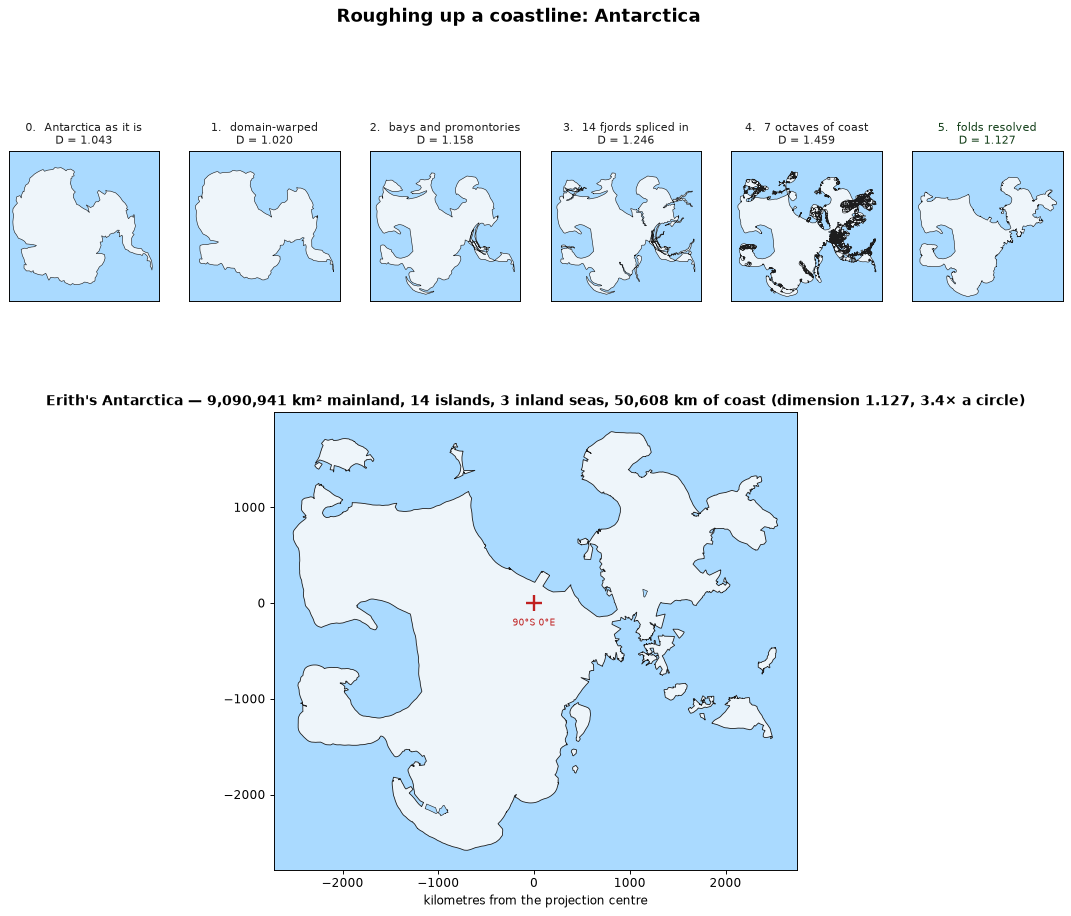

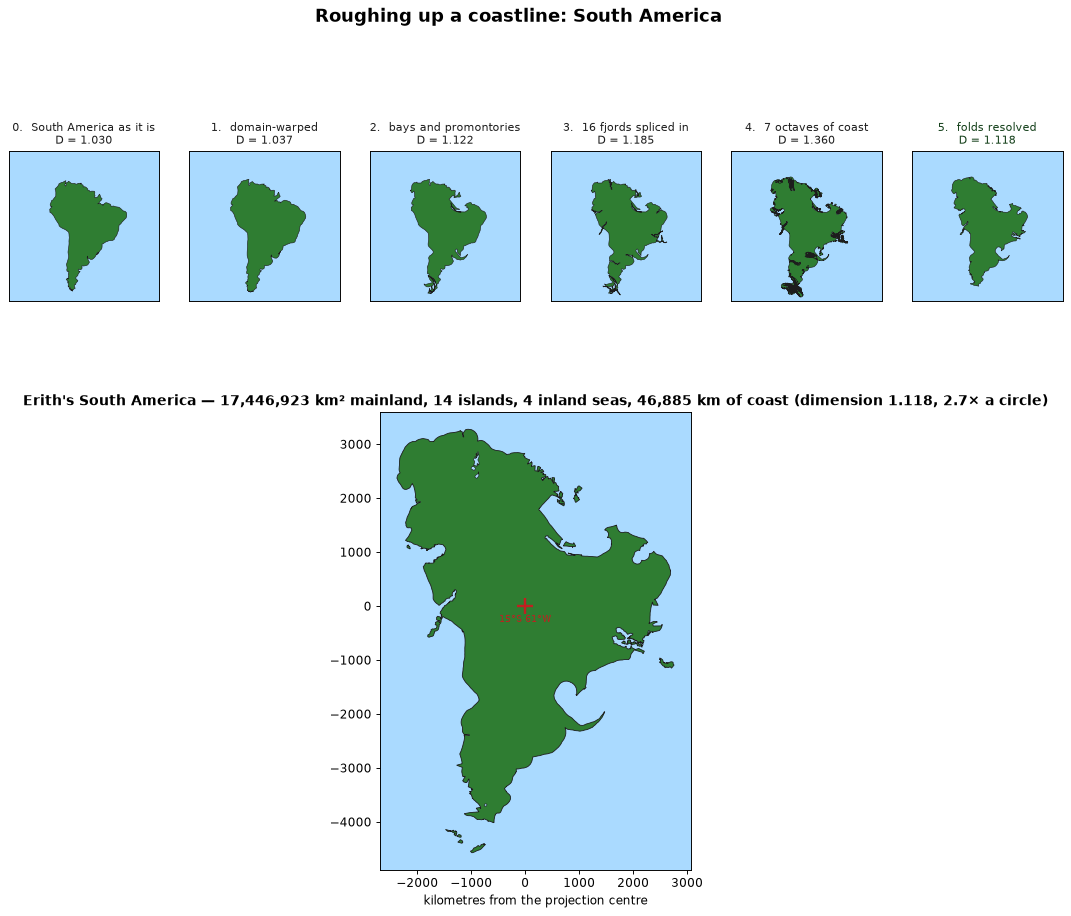

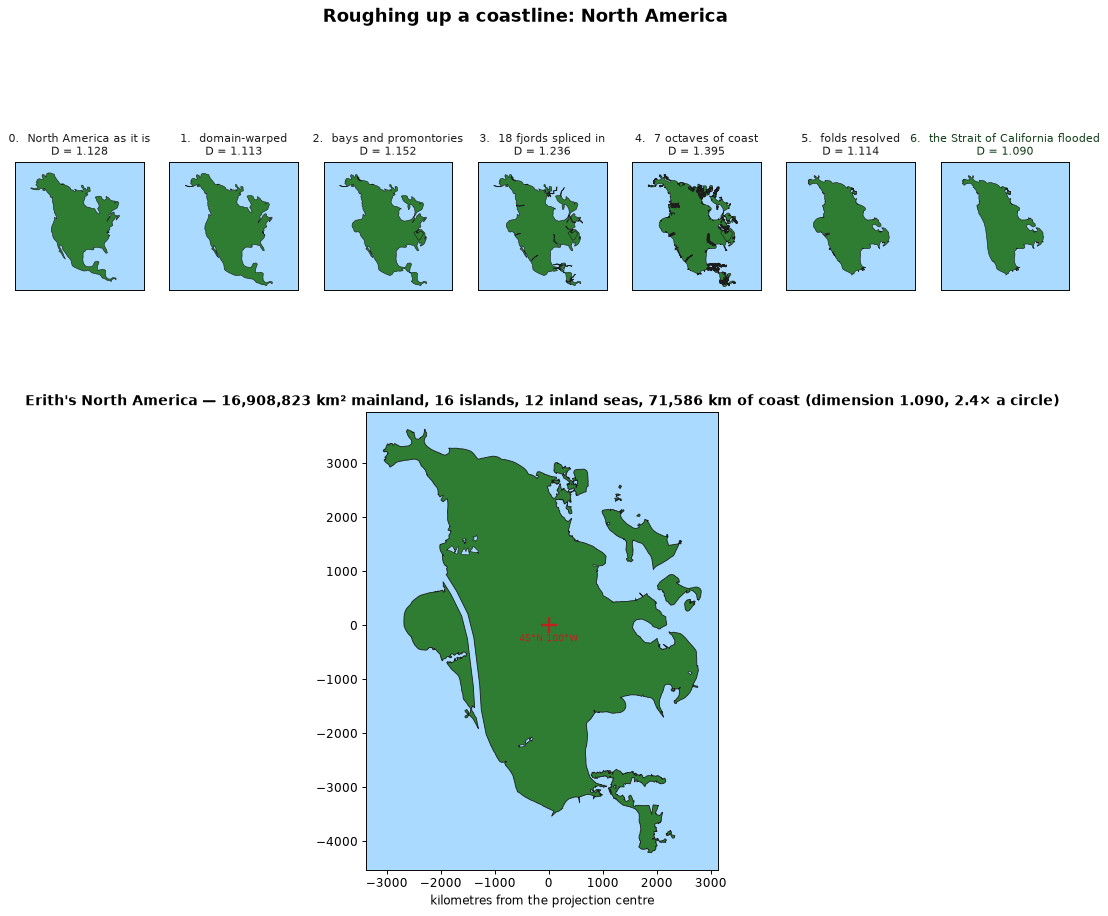

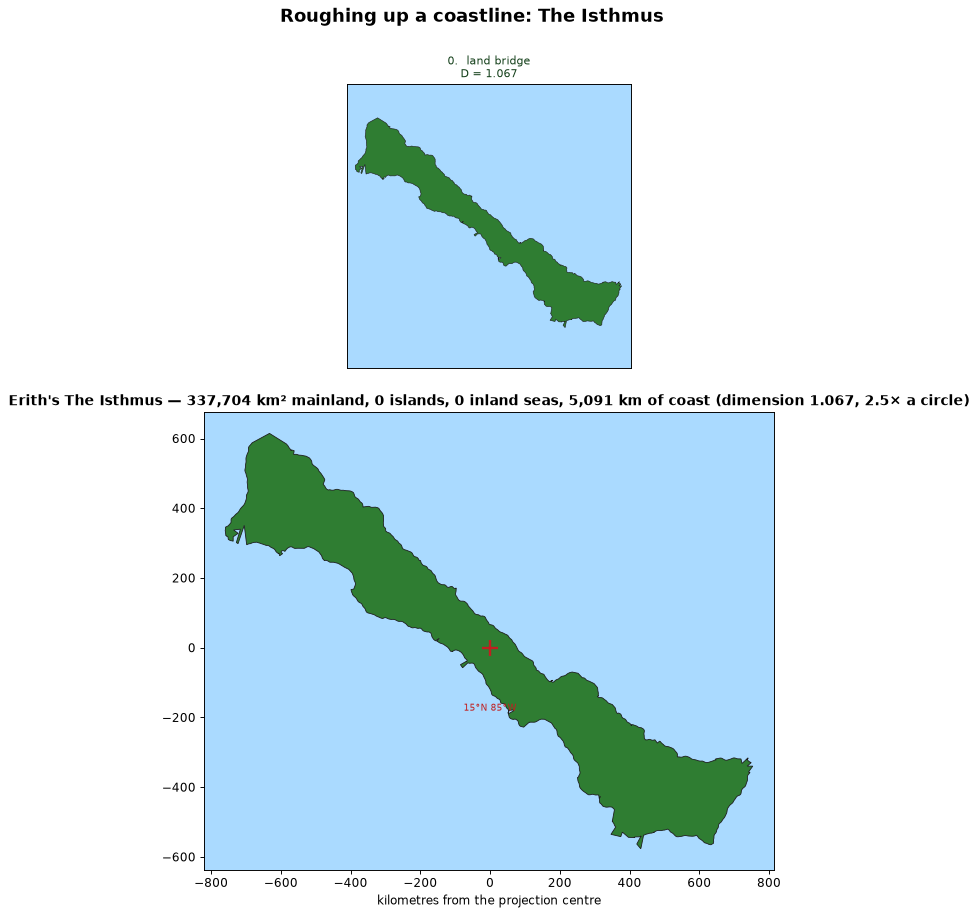

In [15]:
def plot_fractal_landmass(mass):
    """The roughening, stage by stage, and the continent it produces."""
    lim = 1.06 * max(np.abs(np.vstack(mass["land"])).max(),
                     np.abs(np.vstack([s[1] for s in mass["stages"]])).max())
    stages = mass["stages"]
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(2, len(stages), height_ratios=[0.62, 1.0], hspace=0.12)

    for i, (title, ring) in enumerate(stages):
        ax = fig.add_subplot(gs[0, i])
        ax.set_facecolor(SEA_BLUE)
        ax.fill(ring[:, 0], ring[:, 1], facecolor=mass["colour"],
                edgecolor="#1d1d1d", lw=0.5)
        ax.set(xlim=(-lim, lim), ylim=(-lim, lim), xticks=[], yticks=[])
        ax.set_aspect("equal")
        ax.set_title(f"{i}.  {title}\nD = {box_dimension(ring):.3f}", fontsize=9,
                     color="#1d1d1d" if i < len(stages) - 1 else "#14401a")

    ax = fig.add_subplot(gs[1, :])
    ax.set_facecolor(SEA_BLUE)
    for ring in mass["land"]:
        ax.fill(ring[:, 0], ring[:, 1], facecolor=mass["colour"],
                edgecolor="#1d1d1d", lw=0.7, zorder=3)
    for ring in mass["water"]:
        ax.fill(ring[:, 0], ring[:, 1], facecolor=SEA_BLUE,
                edgecolor="#1d1d1d", lw=0.5, zorder=4)
    lon, lat = mass["crs_centre"]
    ax.plot([0], [0], marker="+", color="#c02020", ms=13, mew=2, zorder=6)
    ax.text(0, -160, f"{abs(lat):.0f}°{'S' if lat < 0 else 'N'} "
                     f"{abs(lon):.0f}°{'W' if lon < 0 else 'E'}",
            color="#c02020", ha="center", va="top", fontsize=8, zorder=6)
    st = mass["stats"]
    # The stage strip is framed symmetrically so the panels compare; the main
    # panel follows the continent, which may be nothing like square.
    span = np.vstack(mass["land"])
    pad = 0.04 * max(np.ptp(span[:, 0]), np.ptp(span[:, 1]))
    ax.set(xlim=(span[:, 0].min() - pad, span[:, 0].max() + pad),
           ylim=(span[:, 1].min() - pad, span[:, 1].max() + pad),
           xlabel="kilometres from the projection centre")
    ax.set_aspect("equal")
    ax.set_title(f"Erith's {mass['name']} — {st['mainland_km2']:,.0f} km² mainland, "
                 f"{st['islands']} islands, {st['inland_seas']} inland seas, "
                 f"{st['coast_km']:,.0f} km of coast "
                 f"(dimension {st['dimension']:.3f}, {st['crinkle']:.1f}× a circle)",
                 fontsize=12, fontweight="bold")
    fig.suptitle(f"Roughing up a coastline: {mass['name']}",
                 fontsize=15, fontweight="bold", y=0.955)
    return fig


for mass in FRACTAL.values():
    plot_fractal_landmass(mass)
    plt.show()

## 10. Australia

Menorca is a distorted Australia, so Erith's Australia *is* Menorca — scaled up
and pinned to two fixed points.

**Two point correspondences determine a similarity exactly** (uniform scale,
rotation, translation — four degrees of freedom, and two points supply four
equations). So fixing

* **Mahón** on Sydney's position — 151.209° E, 33.869° S
* **Ciutadella** on Perth's position — 115.861° E, 31.952° S

fixes the size and the bearing of every other point on the coastline. Nothing
else needs choosing.

The anchor line runs 41 km across Menorca and 3,290 km across Erith, so the
scale is **×79.5**; the bearing turns from 286.3° to 263.8°, a rotation of
**+12.3°** once measured in the projection plane. The result covers
**4.35 million km²** against the real Australia's 7.69 million.

### Keeping the ports on the water

Both towns are ports, but Natural Earth's 10 m coastline does not resolve
Mahón's ria, so they sit a couple of km *inside* it — and ×80 turns that into a
couple of hundred km inland.

`snap_anchors_to_coast` fixes this by moving the **source** anchors onto
Menorca's own coastline before the transform is derived, which costs nothing at
the destination: a similarity maps the outline onto the outline, so an anchor
sitting on Menorca's coast lands exactly on Erith's coast *while still hitting
its target lon/lat exactly*. Each anchor is also inserted into the outline as a
vertex, which pins it through the fractal roughening — that only displaces
points between vertices.

`build_landmasses` asserts the result: both towns end up **0 m** from the
coastline. `LANDMASS_SPECS` is a list — add a row to sketch in another landmass.

In [16]:
MENORCA = np.array([
    (4.2980, 39.9420), (4.2859, 39.9446), (4.2701, 39.9438), (4.2546, 39.9497),
    (4.2724, 39.9553), (4.2734, 39.9700), (4.2649, 39.9864), (4.2546, 39.9975),
    (4.2475, 40.0004), (4.2327, 40.0027), (4.2272, 40.0049), (4.2169, 40.0126),
    (4.2125, 40.0172), (4.2067, 40.0248), (4.1786, 40.0388), (4.1726, 40.0459),
    (4.1765, 40.0592), (4.1705, 40.0646), (4.1638, 40.0606), (4.1658, 40.0459),
    (4.1559, 40.0347), (4.1485, 40.0278), (4.1423, 40.0248), (4.1354, 40.0282),
    (4.1349, 40.0357), (4.1370, 40.0430), (4.1391, 40.0459), (4.1168, 40.0596),
    (4.1078, 40.0676), (4.1051, 40.0794), (4.0943, 40.0747), (4.0776, 40.0643),
    (4.0634, 40.0596), (4.0520, 40.0582), (4.0119, 40.0596), (3.9155, 40.0520),
    (3.8915, 40.0596), (3.8219, 40.0476), (3.8095, 40.0354), (3.8071, 40.0233),
    (3.8032, 40.0181), (3.8034, 40.0132), (3.8129, 40.0012), (3.8220, 39.9951),
    (3.8424, 39.9894), (3.8505, 39.9839), (3.8391, 39.9756), (3.8357, 39.9624),
    (3.8349, 39.9480), (3.8307, 39.9361), (3.8693, 39.9255), (3.9413, 39.9368),
    (3.9814, 39.9361), (4.0151, 39.9258), (4.1772, 39.8433), (4.2481, 39.8165),
    (4.3001, 39.8218), (4.3029, 39.8876), (4.3118, 39.8842), (4.3198, 39.8792),
    (4.3263, 39.8734), (4.3303, 39.8672), (4.3371, 39.8672), (4.3288, 39.8834),
    (4.3073, 39.9105), (4.3029, 39.9255)])


def roughen_ring(xy, fraction=0.055, target_step_km=45.0):
    """Fractalise a closed outline in the plane, keeping its vertices fixed.

    A 66-vertex island blown up to continental size reads as a polygon, so each
    edge gets the same multi-octave treatment as Portland's own coastline, with
    an amplitude proportional to the edge it sits on.
    """
    out = []
    for p1, p2 in zip(xy, np.roll(xy, -1, axis=0)):
        length = float(np.hypot(*(p2 - p1)))
        steps = int(np.clip(length / target_step_km, 4, 40))
        out.append(rough_segment(p1, p2, roughness=fraction * length, steps=steps)[:-1])
    return np.vstack(out)


def nearest_on_ring(point, ring):
    """Closest point on a closed polyline: (point, edge index, position along it)."""
    a, b = ring, np.roll(ring, -1, axis=0)
    ab = b - a
    den = np.einsum("ij,ij->i", ab, ab)
    t = np.clip(np.einsum("ij,ij->i", point - a, ab) / np.where(den == 0, 1, den), 0, 1)
    proj = a + t[:, None] * ab
    i = int(np.argmin(np.hypot(*(proj - point).T)))
    return proj[i], i, float(t[i])


def snap_anchors_to_coast(outline, anchors, tol=1e-9):
    """Move each anchor onto the outline, inserting it there as a vertex.

    Mahon and Ciutadella are ports, but Natural Earth's 10m coastline does not
    resolve Mahon's ria, so the towns sit a couple of km inside it -- which the
    x86 magnification turns into a couple of hundred km inland.

    Snapping the *source* anchors costs nothing at the destination. A
    similarity maps the outline onto the outline, so an anchor sitting on
    Menorca's coast lands exactly on Erith's coast while still hitting its
    target lon/lat exactly. Inserting it as a vertex also pins it through the
    fractal roughening, which only displaces points between vertices.

    Returns (outline with the anchors as vertices, snapped anchors, km moved).
    """
    centre = gc_midpoint(*anchors)
    ring = np.column_stack(azeq_project(outline[:, 0], outline[:, 1], centre))

    snapped, inserts, moved = [], [], []
    for anchor in anchors:
        pt = np.array([float(c) for c in azeq_project(*anchor, centre)])
        proj, i, t = nearest_on_ring(pt, ring)
        moved.append(float(np.hypot(*(proj - pt))))
        lon, lat = azeq_unproject(np.array([proj[0]]), np.array([proj[1]]), centre)
        snapped.append((float(lon[0]), float(lat[0])))
        if t > tol and t < 1.0 - tol:            # genuinely mid-edge: insert it
            inserts.append((i + 1, snapped[-1]))

    out = outline
    for idx, pt in sorted(inserts, reverse=True):   # descending, so indices hold
        out = np.insert(out, idx, pt, axis=0)
    return out, snapped, moved


def place_landmass(outline, src_anchors, dst_anchors, roughness=0.055):
    """Place an outline so that two named points land on two given positions.

    A similarity -- uniform scale, rotation, translation -- is exactly
    determined by two point correspondences, so fixing Mahon on Sydney and
    Ciutadella on Perth fixes the size and the bearing of everything else.

    The similarity is applied in azimuthal-equidistant planes centred on each
    pair's great-circle midpoint, which spreads the projection's distortion
    symmetrically across the landmass rather than piling it up at one anchor.
    Both anchors come out exact either way.
    """
    src_c, dst_c = gc_midpoint(*src_anchors), gc_midpoint(*dst_anchors)
    z = lambda p: complex(*(float(c) for c in azeq_project(*p, src_c)))
    w = lambda p: complex(*(float(c) for c in azeq_project(*p, dst_c)))

    # a carries scale and rotation together; b is the translation.
    a = (w(dst_anchors[0]) - w(dst_anchors[1])) / (z(src_anchors[0]) - z(src_anchors[1]))
    b = w(dst_anchors[0]) - a * z(src_anchors[0])

    x, y = azeq_project(outline[:, 0], outline[:, 1], src_c)
    moved = a * (x + 1j * y) + b
    xy = np.column_stack([moved.real, moved.imag])
    if roughness:
        xy = roughen_ring(xy, roughness)

    lon, lat = azeq_unproject(xy[:, 0], xy[:, 1], dst_c)
    area = 0.5 * abs(np.dot(xy[:, 0], np.roll(xy[:, 1], -1))
                     - np.dot(xy[:, 1], np.roll(xy[:, 0], -1)))
    return dict(lon=lon, lat=lat, scale=abs(a),
                rotation_deg=float(np.degrees(np.angle(a))), area_km2=float(area))


LANDMASS_SPECS = [
    dict(name="Australia", outline=MENORCA, colour="#2f7d32",
         source="Menorca",
         anchors=[("Mahón", (4.2658, 39.8885), (151.2093, -33.8688)),     # Sydney
                  ("Ciutadella", (3.8416, 40.0017), (115.8613, -31.9523))],  # Perth
         label_at=(136.0, -26.0)),
]


def point_to_ring_km(point, ring):
    """Shortest distance from a point to a closed polyline, in the same units."""
    a, b = ring, np.roll(ring, -1, axis=0)
    ab = b - a
    denom = np.einsum("ij,ij->i", ab, ab)
    t = np.clip(np.einsum("ij,ij->i", point - a, ab) / np.where(denom == 0, 1, denom), 0, 1)
    return float(np.min(np.hypot(*(a + t[:, None] * ab - point).T)))


def build_landmasses(specs=LANDMASS_SPECS, fractal=None):
    """Collect every landmass into one registry, whatever built it."""
    out = dict(fractal or {})
    for spec in specs:
        names = [a[0] for a in spec["anchors"]]
        src = [a[1] for a in spec["anchors"]]
        dst = [a[2] for a in spec["anchors"]]

        outline, src, moved = snap_anchors_to_coast(spec["outline"], src)
        placed = place_landmass(outline, src, dst)
        placed.update(name=spec["name"], colour=spec["colour"],
                      source=spec["source"], label_at=spec["label_at"],
                      cities=dict(zip(names, dst)), crs_centre=None,
                      land=[np.column_stack([placed["lon"], placed["lat"]])],
                      water=[])

        src_km = gc_distance_km(*src)
        dst_km = gc_distance_km(*dst)
        print(f"{spec['name']}: {spec['source']} scaled x{placed['scale']:.1f}, "
              f"turned {placed['rotation_deg']:+.1f} deg")
        print(f"  {names[0]}-{names[1]} anchor line: {src_km:,.0f} km on "
              f"{spec['source']} -> {dst_km:,.0f} km on Erith "
              f"(bearing {gc_bearing(*src):.1f} -> {gc_bearing(*dst):.1f} deg)")
        print(f"  area {placed['area_km2']:,.0f} km^2, "
              f"spanning lon {placed['lon'].min():.1f}..{placed['lon'].max():.1f}, "
              f"lat {placed['lat'].min():.1f}..{placed['lat'].max():.1f}")

        centre = gc_midpoint(*dst)
        ring = np.column_stack(azeq_project(placed["lon"], placed["lat"], centre))
        for nm, (alon, alat), km in zip(names, dst, moved):
            pt = np.array([float(c) for c in azeq_project(alon, alat, centre)])
            coast_km = point_to_ring_km(pt, ring)
            assert coast_km < 1.0, f"{nm} is {coast_km:.1f} km off the coastline"
            print(f"  {nm:<11} on the coast at {alon:8.3f}, {alat:7.3f} "
                  f"({coast_km * 1000:.0f} m off it; source anchor moved "
                  f"{km:.1f} km on {spec['source']})")
        out[spec["name"]] = placed
    return out


LANDMASSES = build_landmasses(fractal=FRACTAL)

Australia: Menorca scaled x79.5, turned +12.3 deg
  Mahón-Ciutadella anchor line: 41 km on Menorca -> 3,290 km on Erith (bearing 286.3 -> 263.8 deg)
  area 4,351,391 km^2, spanning lon 113.4..154.3, lat -40.4..-22.9
  Mahón       on the coast at  151.209, -33.869 (0 m off it; source anchor moved 3.2 km on Menorca)
  Ciutadella  on the coast at  115.861, -31.952 (0 m off it; source anchor moved 1.3 km on Menorca)


## 11. Erith

`build_isthmus` closes the gap between the two Americas with a land bridge,
narrowest at its waist and run a little way *into* each continent so the three
polygons overlap and read as one coast. That choice has consequences beyond the
map: a closed isthmus is what gives a planet a modern Atlantic overturning
circulation, and so a Gulf Stream, and so a Portland that is temperate rather
than subarctic at 50–58° N.

The landmasses are spread across the whole planet and no single globe holds
them, so: three hemispheres above, and the world laid flat below. Each is drawn
straight from its own projection plane through a matching cartopy CRS, which
sidesteps the antimeridian entirely.

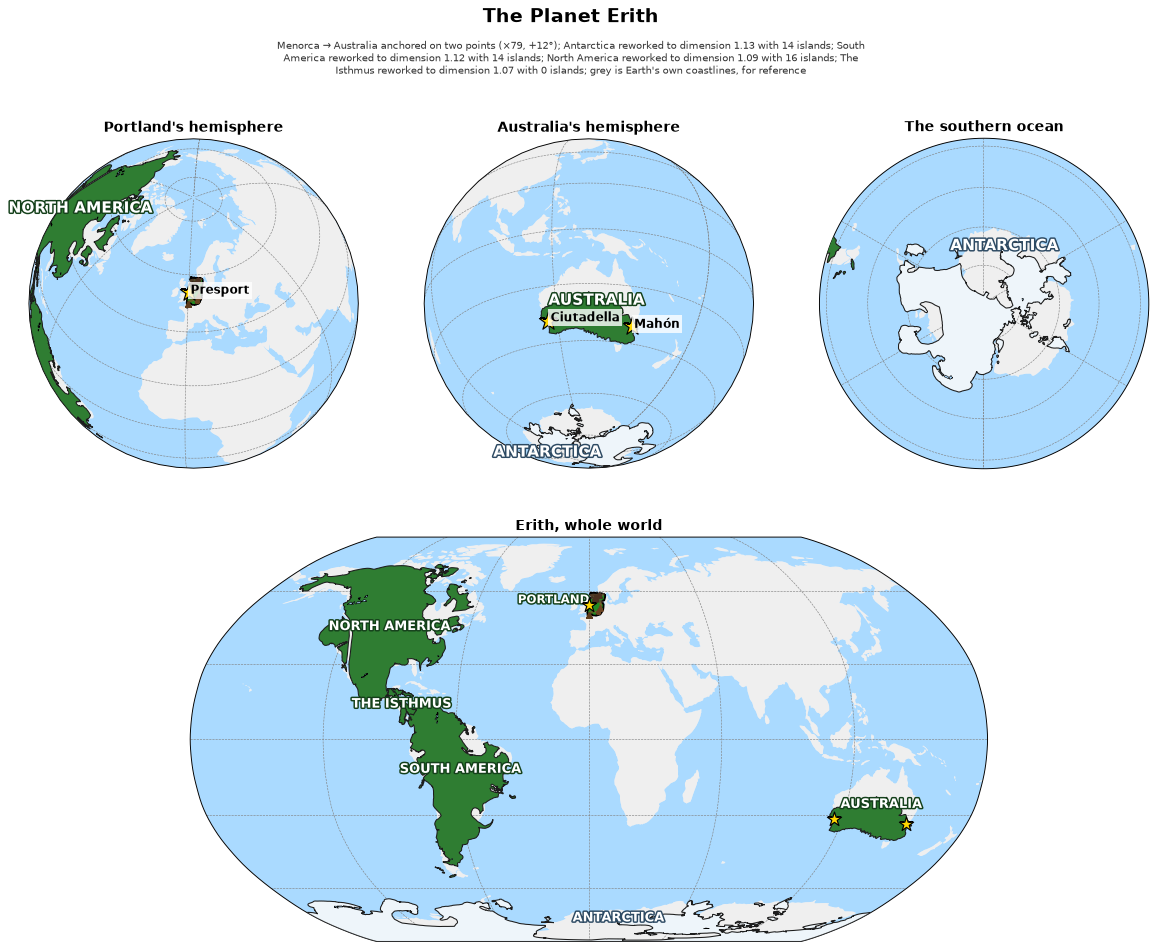

In [17]:
def _draw_portland(ax, world, rivers, flat, lw_k, sz_k, with_rivers):
    ax.fill(*km_to_lonlat(*world["coast"].T), transform=flat, color="#228B22",
            edgecolor="black", linewidth=1.2, zorder=5)
    for crest in world["ranges"].values():
        lon, lat = km_to_lonlat(crest["x"], crest["y"])
        ax.plot(lon, lat, transform=flat, color=crest["colour"],
                lw=crest["lw"] * lw_k, alpha=0.7, zorder=6)
        peaks = np.argsort(crest["h"])[-crest["markers"]:]   # summits only
        ax.scatter(lon[peaks], lat[peaks], transform=flat, marker="^",
                   s=crest["size"] * sz_k, color=crest["dark"], zorder=7)

    if with_rivers and rivers is not None:
        seg = rivers["segments"]
        lon0, lat0 = km_to_lonlat(seg[:, 0, 0], seg[:, 0, 1])
        lon1, lat1 = km_to_lonlat(seg[:, 1, 0], seg[:, 1, 1])
        scale = np.sqrt(rivers["discharge"] / rivers["discharge"].max())
        ax.add_collection(LineCollection(
            np.stack([np.column_stack([lon0, lat0]),
                      np.column_stack([lon1, lat1])], axis=1),
            transform=flat, linewidths=0.3 + 2.4 * scale,
            colors=RIVER_CMAP(0.15 + 0.85 * scale), zorder=8))


def _continent_label(ax, lon, lat, name, flat, fontsize=12, halo="#14401a"):
    """Landmass name, haloed so it stays readable over land or sea."""
    ax.text(lon, lat, name.upper(), transform=flat, fontsize=fontsize,
            fontweight="bold", color="white", ha="center", va="center", zorder=9,
            path_effects=[patheffects.withStroke(linewidth=2.5, foreground=halo)])


def _city(ax, lon, lat, name, flat, fs=11, label=True, dx=1.2, dy=-0.4):
    """A settlement marker; the name is dropped where the map is too small."""
    ax.scatter(lon, lat, transform=flat, color="gold", edgecolor="black",
               marker="*", s=160 if not label else 260, zorder=10)
    if label:
        ax.text(lon + dx, lat + dy, name, transform=flat, fontsize=fs,
                fontweight="bold", zorder=11,
                bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2))


def erith_azeq_crs(centre):
    """Cartopy CRS matching `azeq_project` about `centre`, on Erith's sphere.

    Each fractal landmass keeps its rings in the plane it was flattened into,
    and is drawn back through the matching CRS -- so Antarctica never has to be
    expressed in lon/lat, where a pole-encircling coastline is a mess of
    antimeridian seams.
    """
    import cartopy.crs as ccrs
    return ccrs.AzimuthalEquidistant(
        central_longitude=centre[0], central_latitude=centre[1],
        globe=ccrs.Globe(ellipse=None, semimajor_axis=ERITH_RADIUS_KM * 1000.0,
                         semiminor_axis=ERITH_RADIUS_KM * 1000.0))


def _draw_landmass(ax, mass, flat):
    """Fill a landmass's land rings, then punch its inland seas back out."""
    centre = mass.get("crs_centre")
    transform, scale = ((flat, 1.0) if centre is None
                        else (erith_azeq_crs(centre), 1000.0))
    for ring in mass["land"]:
        ax.fill(ring[:, 0] * scale, ring[:, 1] * scale, transform=transform,
                facecolor=mass["colour"], edgecolor="#1d1d1d", linewidth=0.9,
                zorder=5)
    for ring in mass["water"]:
        ax.fill(ring[:, 0] * scale, ring[:, 1] * scale, transform=transform,
                facecolor=SEA_BLUE, edgecolor="black", linewidth=0.5, zorder=6)


def plot_planet(world, rivers=None, landmasses=None, reference=True):
    """Erith: three hemispheres above, and the whole world laid flat below."""
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    landmasses = landmasses or {}
    flat = ccrs.PlateCarree()
    pres_lon, pres_lat = km_to_lonlat(*world["cities"]["Presport"])

    fig = plt.figure(figsize=(17, 13))
    gs = fig.add_gridspec(2, 3, height_ratios=[1.0, 0.95], hspace=0.05)
    # (title, projection, cell, viewpoint) -- the viewpoint decides which labels
    # a hemisphere can show; None means the whole world is in view.
    panels = [
        ("Portland's hemisphere", ccrs.Orthographic(3.0, 50.0), gs[0, 0], (3.0, 50.0)),
        ("Australia's hemisphere", ccrs.Orthographic(133.0, -27.0), gs[0, 1],
         (133.0, -27.0)),
        ("The southern ocean", ccrs.SouthPolarStereo(), gs[0, 2], None),
        # Centred on 0, so the map's edge falls in the empty Pacific rather than
        # through North America, which spans 166 W to 61 W.
        ("Erith, whole world", ccrs.Robinson(central_longitude=0.0), gs[1, :], None),
    ]

    for title, proj, cell, viewpoint in panels:
        world_map = isinstance(proj, ccrs.Robinson)
        south = isinstance(proj, ccrs.SouthPolarStereo)
        ax = fig.add_subplot(cell, projection=proj)
        if south:
            ax.set_extent([-180, 180, -90, -48], crs=flat)
            # The classic round polar map, rather than a square crop of one.
            t = np.linspace(0, 2 * np.pi, 200)
            ax.set_boundary(MplPath(np.column_stack([0.5 + 0.5 * np.sin(t),
                                                     0.5 + 0.5 * np.cos(t)])),
                            transform=ax.transAxes)
        else:
            ax.set_global()
        ax.add_feature(cfeature.OCEAN, facecolor=SEA_BLUE)
        if reference:
            ax.add_feature(cfeature.LAND, facecolor="#d3d3d3", alpha=0.35)
        ax.gridlines(color="gray", linestyle="--", linewidth=0.5)

        # Cartopy clips patches to the panel but not text, so a label placed
        # outside the view would be drawn on the limb -- or stretch the saved
        # figure. Only label what this panel can actually show.
        if south:
            shows = lambda lon, lat: lat < -45.0
        elif viewpoint is not None:
            # Well inside the limb, not merely on the visible side: a label at
            # 85 deg from the viewpoint sits on a sliver of foreshortened coast.
            shows = lambda lon, lat: (
                np.degrees(gc_distance_km((lon, lat), viewpoint) / ERITH_RADIUS_KM) < 75.0)
        else:
            shows = lambda lon, lat: True

        if shows(pres_lon, pres_lat):
            _draw_portland(ax, world, rivers, flat,
                           lw_k=0.35, sz_k=0.10, with_rivers=False)
            _city(ax, pres_lon, pres_lat, "Presport", flat, fs=10,
                  label=not world_map)
            if world_map:
                # At world scale Portland is a speck, so it gets a name instead.
                _continent_label(ax, -19.0, 56.0, "Portland", flat, fontsize=10)

        for mass in landmasses.values():
            _draw_landmass(ax, mass, flat)
            llon, llat = mass["label_at"]
            if shows(llon, llat):
                _continent_label(ax, llon, llat, mass["name"], flat,
                                 fontsize=11 if world_map else 13,
                                 halo=mass.get("halo", "#14401a"))
            for nm, (clon, clat) in mass["cities"].items():
                if shows(clon, clat):
                    _city(ax, clon, clat, nm, flat, fs=10, label=not world_map)

        ax.set_title(title, fontsize=12, fontweight="bold")

    clauses = (
        [f"{m['source']} → {m['name']} anchored on two points "
         f"(×{m['scale']:.0f}, {m['rotation_deg']:+.0f}°)"
         for m in landmasses.values() if "scale" in m]
        + [f"{m['name']} reworked to dimension {m['stats']['dimension']:.2f} "
           f"with {m['stats']['islands']} islands"
           for m in landmasses.values() if "stats" in m])
    if reference:
        clauses.append("grey is Earth's own coastlines, for reference")
    # Wrapped: one long line would stretch the whole figure to fit it.
    note = textwrap.fill("; ".join(clauses), width=118)
    fig.suptitle("The Planet Erith", fontsize=16, fontweight="bold", y=0.955)
    fig.text(0.5, 0.926, note, ha="center", va="top", fontsize=8.5, color="#333333")
    return fig


plot_planet(WORLD, RIVERS, LANDMASSES)
plt.show()